# Prédiction COVID-19 avec des Réseaux de Neurones Récurrents
## GRU amélioré · LSTM amélioré · BiLSTM amélioré

**Projet Deep Learning — Master 1 IA, Université de Béjaïa — 2025/2026**

## 1. Bibliothèques

In [ ]:
import sys
!{sys.executable} -m pip install torch torchvision --quiet

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn

sns.set(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)
print("✅ Imports OK")

✅ Imports OK


## 2. Chargement des données (Johns Hopkins)

In [ ]:
url_confirmed = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
url_deaths    = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv"
url_recovered = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_recovered_global.csv"

df_confirmed = pd.read_csv(url_confirmed)
df_deaths    = pd.read_csv(url_deaths)
df_recovered = pd.read_csv(url_recovered)

print("✅ Données chargées")
print("Confirmed :", df_confirmed.shape)
print(df_confirmed.head(3))

✅ Données chargées
Confirmed : (289, 1147)
  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0            NaN    Afghanistan  33.93911  67.709953        0        0   
1            NaN        Albania  41.15330  20.168300        0        0   
2            NaN        Algeria  28.03390   1.659600        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...  2/28/23  3/1/23  3/2/23  3/3/23  \
0        0        0        0        0  ...   209322  209340  209358  209362   
1        0        0        0        0  ...   334391  334408  334408  334427   
2        0        0        0        0  ...   271441  271448  271463  271469   

   3/4/23  3/5/23  3/6/23  3/7/23  3/8/23  3/9/23  
0  209369  209390  209406  209436  209451  209451  
1  334427  334427  334427  334427  334443  334457  
2  271469  271477  271477  271490  271494  271496  

[3 rows x 1147 columns]


In [ ]:
print("Colonnes disponibles :", df_confirmed.columns.tolist()[:10], "...")

Colonnes disponibles : ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20'] ...


## 3. Fusion des datasets

In [ ]:
def aggregate_country_date(df, value_name):
    """
    Groupe par Country/Region + Date AVANT le melt.
    Réduit massivement la taille en RAM (évite le MemoryError).
    """
    date_cols = [c for c in df.columns if c not in
                 ['Province/State', 'Country/Region', 'Lat', 'Long']]
    df_agg = (df.drop(columns=['Province/State', 'Lat', 'Long'])
                .groupby('Country/Region')[date_cols]
                .sum()
                .reset_index())
    df_melted = df_agg.melt(
        id_vars=['Country/Region'],
        var_name='Date',
        value_name=value_name
    )
    # Format explicite pour éviter le UserWarning
    df_melted['Date'] = pd.to_datetime(df_melted['Date'], format='%m/%d/%y')
    return df_melted

print("Agrégation en cours...")
df_c = aggregate_country_date(df_confirmed, 'Confirmed')
df_d = aggregate_country_date(df_deaths,    'Deaths')
df_r = aggregate_country_date(df_recovered, 'Recovered')

df = df_c.merge(df_d[['Country/Region','Date','Deaths']],
                on=['Country/Region','Date'], how='left')
df = df.merge(df_r[['Country/Region','Date','Recovered']],
              on=['Country/Region','Date'], how='left')
df = df.fillna(0)
print("✅ Dataset fusionné :", df.shape)
print(df.head(3))

Agrégation en cours...
✅ Dataset fusionné : (229743, 5)
  Country/Region       Date  Confirmed  Deaths  Recovered
0    Afghanistan 2020-01-22          0       0          0
1        Albania 2020-01-22          0       0          0
2        Algeria 2020-01-22          0       0          0


## 4. Exploration et visualisation des données

### 4.1 Évolution des cas — France, Italie, États-Unis

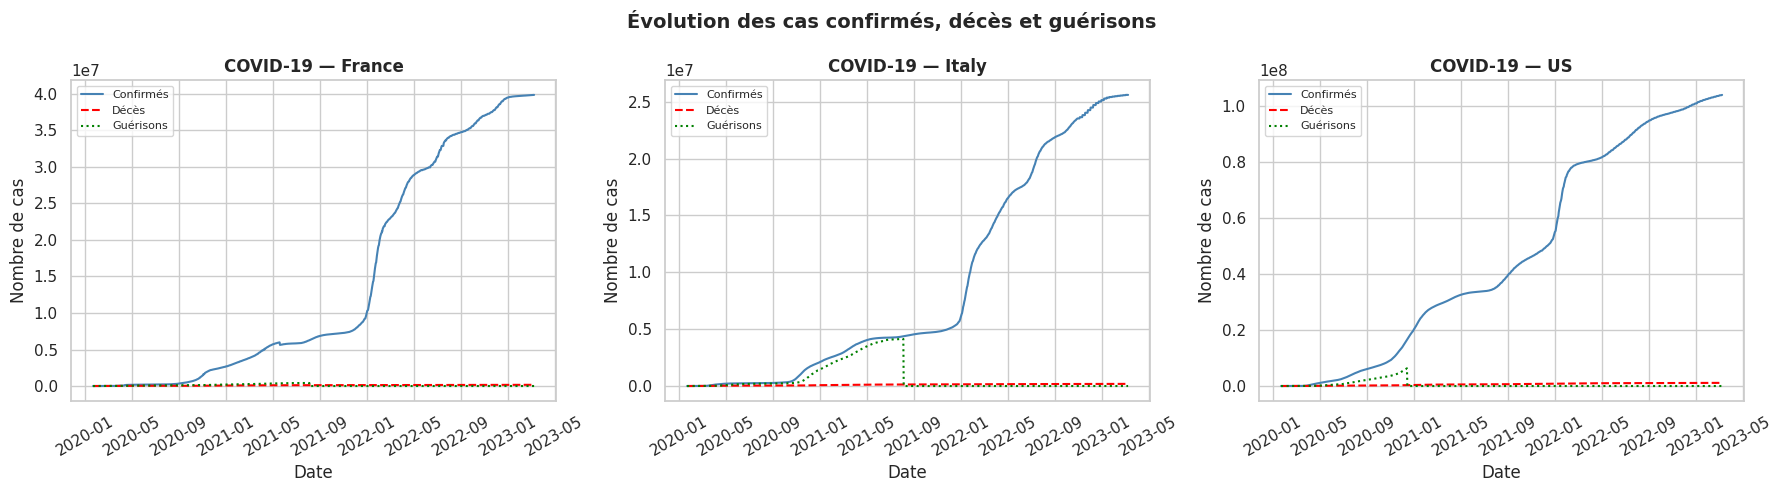

✅ Figure sauvegardée : fig_evolution_pays.png


In [ ]:
# CORRECTION : on sélectionne uniquement les colonnes numériques avant groupby
NUMERIC_COLS = ['Confirmed', 'Deaths', 'Recovered']
target_countries = ["France", "Italy", "US"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, country in zip(axes, target_countries):
    df_country = (df[df["Country/Region"] == country]
                  .groupby("Date")[NUMERIC_COLS]   # ← colonnes numériques uniquement
                  .sum()
                  .reset_index())

    ax.plot(df_country["Date"], df_country["Confirmed"],
            label="Confirmés", color="steelblue", lw=1.5)
    ax.plot(df_country["Date"], df_country["Deaths"],
            label="Décès",     color="red",       lw=1.5, linestyle="--")
    ax.plot(df_country["Date"], df_country["Recovered"],
            label="Guérisons", color="green",     lw=1.5, linestyle=":")
    ax.set_title(f"COVID-19 — {country}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Date"); ax.set_ylabel("Nombre de cas")
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

plt.suptitle("Évolution des cas confirmés, décès et guérisons",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_evolution_pays.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_evolution_pays.png")

### 4.2 Top 10 pays par nombre de cas

In [ ]:
latest_date = df['Date'].max()
top10 = (df[df['Date'] == latest_date]
         .groupby("Country/Region")['Confirmed']
         .sum()
         .sort_values(ascending=False)
         .head(10))
print(f"Top 10 pays au {latest_date.date()}")
print(top10)

Top 10 pays au 2023-03-09
Country/Region
US                103802702
India              44690738
France             39866718
Germany            38249060
Brazil             37076053
Japan              33320438
Korea, South       30615522
Italy              25603510
United Kingdom     24658705
Russia             22075858
Name: Confirmed, dtype: int64


## 5. Prétraitement — Cas cumulatifs confirmés en France

In [ ]:
COUNTRY = 'France'
SEQ_LEN = 60   # fenêtre glissante de 60 jours

# Extraction et tri France
df_target2 = (df[df['Country/Region'] == COUNTRY]
              .groupby('Date')[['Confirmed', 'Deaths', 'Recovered']]
              .sum()
              .reset_index()
              .sort_values('Date'))

# Cas journaliers (pour visualisation)
df_target2['Daily_Confirmed'] = (df_target2['Confirmed']
                                  .diff().fillna(0).clip(lower=0))

print("✅ Données France extraites :", df_target2.shape)
print(df_target2[['Date','Confirmed','Daily_Confirmed']].tail(5))

✅ Données France extraites : (1143, 5)
           Date  Confirmed  Daily_Confirmed
1138 2023-03-05   39839090              0.0
1139 2023-03-06   39847236           8146.0
1140 2023-03-07   39854299           7063.0
1141 2023-03-08   39860410           6111.0
1142 2023-03-09   39866718           6308.0


### 5.1 Cas journaliers en France

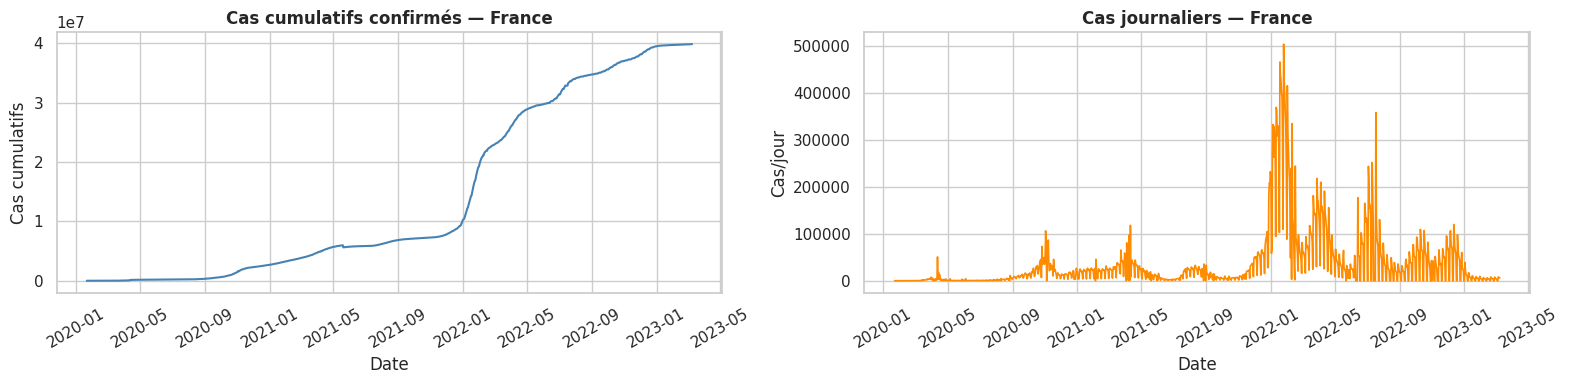

✅ Figure sauvegardée : fig_cas_journaliers.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df_target2['Date'], df_target2['Confirmed'],
             color='steelblue', lw=1.5)
axes[0].set_title("Cas cumulatifs confirmés — France", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(df_target2['Date'], df_target2['Daily_Confirmed'],
             color='darkorange', lw=1.2)
axes[1].set_title("Cas journaliers — France", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Cas/jour")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("fig_cas_journaliers.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_cas_journaliers.png")

### 5.2 Normalisation et création des séquences (fenêtre glissante)

In [ ]:
# Normalisation MinMax sur les cas CUMULATIFS
scaler2 = MinMaxScaler()
data_scaled2 = scaler2.fit_transform(df_target2[['Confirmed']])

# Création des séquences : Xi = (x_i, ..., x_{i+L-1}), yi = x_{i+L}
X2, y2 = [], []
for i in range(len(data_scaled2) - SEQ_LEN):
    X2.append(data_scaled2[i : i + SEQ_LEN])
    y2.append(data_scaled2[i + SEQ_LEN])
X2, y2 = np.array(X2), np.array(y2)

# Partitionnement 70% / 15% / 15%
n2 = len(X2)
X_train2 = torch.FloatTensor(X2[:int(n2*0.70)])
y_train2 = torch.FloatTensor(y2[:int(n2*0.70)])
X_val2   = torch.FloatTensor(X2[int(n2*0.70):int(n2*0.85)])
y_val2   = torch.FloatTensor(y2[int(n2*0.70):int(n2*0.85)])
X_test2  = torch.FloatTensor(X2[int(n2*0.85):])
y_test2  = torch.FloatTensor(y2[int(n2*0.85):])

print(f"Séquences totales : {n2}")
print(f"Train : {X_train2.shape} | Val : {X_val2.shape} | Test : {X_test2.shape}")

Séquences totales : 1083
Train : torch.Size([758, 60, 1]) | Val : torch.Size([162, 60, 1]) | Test : torch.Size([163, 60, 1])


## 6. Fonction d'évaluation

In [ ]:
def evaluate2(model, Xt, yt, name, scaler=scaler2):
    """
    Calcule et affiche :
      - MAE / RMSE normalisés [0-1]  → comparables à la littérature
      - MAE / RMSE réels             → en nombre de cas cumulés
      - R²  calculé sur valeurs réelles (invariant à l'échelle)
    Retourne : (preds_real, true_real)
    """
    model.eval()
    with torch.no_grad():
        preds_norm = model(Xt).numpy()
        true_norm  = yt.numpy()

    # Métriques normalisées (petits nombres, comparables aux articles)
    mae_norm  = mean_absolute_error(true_norm, preds_norm)
    rmse_norm = np.sqrt(mean_squared_error(true_norm, preds_norm))

    # Dénormalisation
    preds_real = scaler.inverse_transform(preds_norm)
    true_real  = scaler.inverse_transform(true_norm)
    r2         = r2_score(true_real, preds_real)
    mae_real   = mean_absolute_error(true_real, preds_real)
    rmse_real  = np.sqrt(mean_squared_error(true_real, preds_real))

    print(f"\n{'='*44}")
    print(f"  {name}")
    print(f"{'='*44}")
    print(f"  MAE  normalisé  : {mae_norm:.6f}")
    print(f"  RMSE normalisé  : {rmse_norm:.6f}")
    print(f"  {'─'*37}")
    print(f"  MAE  réel       : {mae_real:>18,.2f}  cas")
    print(f"  RMSE réel       : {rmse_real:>18,.2f}  cas")
    print(f"  {'─'*37}")
    print(f"  R²              : {r2:.4f}  ({r2*100:.2f}%)")

    return preds_real, true_real

print("✅ evaluate2 définie")

✅ evaluate2 définie


## 7. Fonction d'entraînement commune

In [ ]:
def train_ameliore(model, Xtr, ytr, Xv, yv, epochs=700, lr=0.001):
    """
    Entraînement avec :
      - Optimiseur AdamW + weight_decay
      - Scheduler ReduceLROnPlateau (patience=30, factor=0.5)
      - Gradient clipping (max_norm=1.0)
      - Early stopping (patience=100)
      - Sauvegarde du meilleur état (best checkpoint)
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=30, factor=0.5
    )

    best_val   = float("inf")
    best_state = None
    patience   = 100
    wait       = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(Xtr)
        loss = criterion(pred, ytr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xv), yv).item()

        scheduler.step(val_loss)
        train_losses.append(loss.item())
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait       = 0
        else:
            wait += 1

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:>4} | Train: {loss.item():.6f} | Val: {val_loss:.6f}")

        if wait >= patience:
            print(f"  ⏹ Early stopping à epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    print(f"  ✅ Meilleur Val Loss : {best_val:.6f}")
    return train_losses, val_losses

print("✅ train_ameliore définie")

✅ train_ameliore définie


## 8. Modèle GRU amélioré

Architecture : GRU(128 neurones, 2 couches) + connexion résiduelle

Formule : $\hat{y}_{t+1} = x_t + \alpha \cdot f_\theta(x_{t-L+1}, \ldots, x_t)$

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

class GRUAmeliore(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1, hidden_size=128,
            num_layers=2, batch_first=True, dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
        # Init proche de zéro → prédiction ≈ dernière valeur au départ
        nn.init.normal_(self.fc[-1].weight, mean=0.0, std=1e-4)
        nn.init.zeros_(self.fc[-1].bias)

    def forward(self, x):
        out, _ = self.gru(x)
        last_value = x[:, -1, :]            # dernière valeur de la fenêtre
        delta      = self.fc(out[:, -1, :]) * 0.05   # correction apprise
        return last_value + delta

gru_ameliore = GRUAmeliore()
n_params = sum(p.numel() for p in gru_ameliore.parameters())
print(f"GRU amélioré — Paramètres : {n_params:,}")

print("\n=== Entraînement GRU amélioré ===")
gru_tl, gru_vl = train_ameliore(
    gru_ameliore, X_train2, y_train2, X_val2, y_val2, epochs=700
)

GRU amélioré — Paramètres : 157,697

=== Entraînement GRU amélioré ===
Epoch   50 | Train: 0.000002 | Val: 0.000022
Epoch  100 | Train: 0.000002 | Val: 0.000015
  ⏹ Early stopping à epoch 112
  ✅ Meilleur Val Loss : 0.000002


## 9. Modèle LSTM amélioré

Architecture : LSTM(128 neurones, 2 couches) + connexion résiduelle

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

class LSTMAmeliore(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=128,
            num_layers=2, batch_first=True, dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
        nn.init.normal_(self.fc[-1].weight, mean=0.0, std=1e-4)
        nn.init.zeros_(self.fc[-1].bias)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_value = x[:, -1, :]
        delta      = self.fc(out[:, -1, :]) * 0.05
        return last_value + delta

lstm_ameliore = LSTMAmeliore()
n_params = sum(p.numel() for p in lstm_ameliore.parameters())
print(f"LSTM amélioré — Paramètres : {n_params:,}")

print("\n=== Entraînement LSTM amélioré ===")
lstm_tl, lstm_vl = train_ameliore(
    lstm_ameliore, X_train2, y_train2, X_val2, y_val2, epochs=700
)

LSTM amélioré — Paramètres : 207,489

=== Entraînement LSTM amélioré ===
Epoch   50 | Train: 0.000003 | Val: 0.000002
Epoch  100 | Train: 0.000003 | Val: 0.000002
  ⏹ Early stopping à epoch 114
  ✅ Meilleur Val Loss : 0.000002


## 10. Modèle BiLSTM amélioré

Architecture : BiLSTM(128 neurones, 2 couches, bidirectionnel) + connexion résiduelle

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

class BiLSTMAmeliore(nn.Module):
    def __init__(self):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=1, hidden_size=128,
            num_layers=2, batch_first=True,
            dropout=0.2, bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 2, 64),   # *2 car bidirectionnel
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
        nn.init.normal_(self.fc[-1].weight, mean=0.0, std=1e-4)
        nn.init.zeros_(self.fc[-1].bias)

    def forward(self, x):
        out, _ = self.bilstm(x)
        last_value = x[:, -1, :]
        delta      = self.fc(out[:, -1, :]) * 0.05
        return last_value + delta

bilstm_ameliore = BiLSTMAmeliore()
n_params = sum(p.numel() for p in bilstm_ameliore.parameters())
print(f"BiLSTM amélioré — Paramètres : {n_params:,}")

print("\n=== Entraînement BiLSTM amélioré ===")
bilstm_tl, bilstm_vl = train_ameliore(
    bilstm_ameliore, X_train2, y_train2, X_val2, y_val2, epochs=700
)

BiLSTM amélioré — Paramètres : 545,921

=== Entraînement BiLSTM amélioré ===
Epoch   50 | Train: 0.000003 | Val: 0.000002
Epoch  100 | Train: 0.000003 | Val: 0.000002
  ⏹ Early stopping à epoch 110
  ✅ Meilleur Val Loss : 0.000002


## 11. Courbes d'apprentissage (Train Loss / Val Loss)

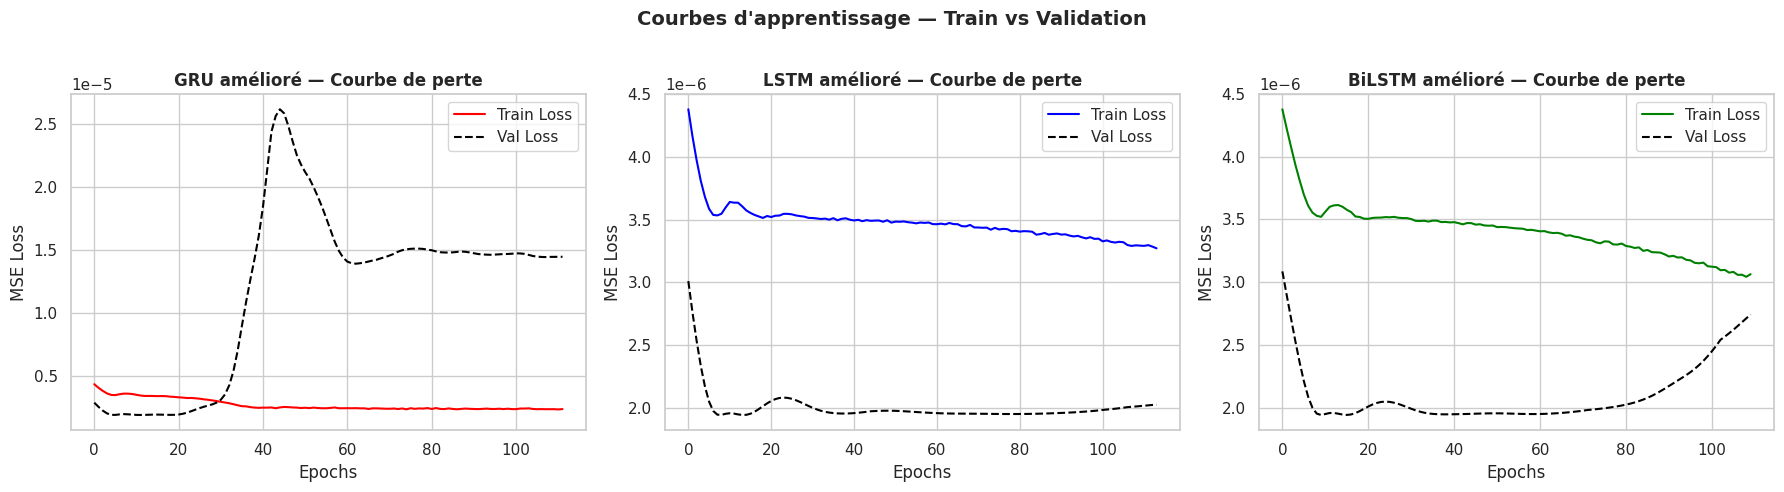

✅ Figure sauvegardée : fig_loss_lstm_gru.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (gru_tl,    gru_vl,    "GRU amélioré",    "red"),
    (lstm_tl,   lstm_vl,   "LSTM amélioré",   "blue"),
    (bilstm_tl, bilstm_vl, "BiLSTM amélioré", "green"),
]

for ax, (tl, vl, name, color) in zip(axes, configs):
    ax.plot(tl, label='Train Loss', color=color,   lw=1.5)
    ax.plot(vl, label='Val Loss',   color='black', lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Courbe de perte", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epochs"); ax.set_ylabel("MSE Loss")
    ax.legend()

plt.suptitle("Courbes d'apprentissage — Train vs Validation",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_loss_lstm_gru.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_loss_lstm_gru.png")

## 12. Évaluation sur l'ensemble de test

In [ ]:
print("\n" + "="*52)
print("   ÉVALUATION COMPLÈTE DES MODÈLES CUMULATIFS")
print("="*52)

gru_preds2,   true_vals2   = evaluate2(gru_ameliore,    X_test2, y_test2, "GRU amélioré")
lstm_preds2,  _            = evaluate2(lstm_ameliore,   X_test2, y_test2, "LSTM amélioré")
bilstm_preds, true_vals_bi = evaluate2(bilstm_ameliore, X_test2, y_test2, "BiLSTM amélioré")


   ÉVALUATION COMPLÈTE DES MODÈLES CUMULATIFS

  GRU amélioré
  MAE  normalisé  : 0.000868
  RMSE normalisé  : 0.000959
  ─────────────────────────────────────
  MAE  réel       :          34,622.41  cas
  RMSE réel       :          38,248.67  cas
  ─────────────────────────────────────
  R²              : 0.9992  (99.92%)

  LSTM amélioré
  MAE  normalisé  : 0.000861
  RMSE normalisé  : 0.000952
  ─────────────────────────────────────
  MAE  réel       :          34,338.48  cas
  RMSE réel       :          37,935.75  cas
  ─────────────────────────────────────
  R²              : 0.9993  (99.93%)

  BiLSTM amélioré
  MAE  normalisé  : 0.000858
  RMSE normalisé  : 0.000947
  ─────────────────────────────────────
  MAE  réel       :          34,200.61  cas
  RMSE réel       :          37,757.45  cas
  ─────────────────────────────────────
  R²              : 0.9993  (99.93%)


## 13. Tableau comparatif final

In [ ]:
print("\n" + "="*70)
print(f"  {'Modèle':<22} {'MAE norm':>11}  {'RMSE norm':>11}  {'R²':>10}")
print("="*70)

results_table = [
    ("GRU amélioré",    gru_preds2,   true_vals2),
    ("LSTM amélioré",   lstm_preds2,  true_vals2),
    ("BiLSTM amélioré", bilstm_preds, true_vals_bi),
]

best_r2   = -np.inf
best_name = ""

for name, preds, trues in results_table:
    p_n    = scaler2.transform(preds)
    t_n    = scaler2.transform(trues)
    mae_n  = mean_absolute_error(t_n, p_n)
    rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
    r2_val = r2_score(trues, preds) * 100
    print(f"  {name:<22} {mae_n:>11.6f}  {rmse_n:>11.6f}  {r2_val:>9.2f}%")
    if r2_val > best_r2:
        best_r2   = r2_val
        best_name = name

print("="*70)
print(f"  🏆 Meilleur modèle : {best_name}  (R² = {best_r2:.2f}%)")
print("="*70)


  Modèle                    MAE norm    RMSE norm          R²
  GRU amélioré              0.000868     0.000959      99.92%
  LSTM amélioré             0.000861     0.000952      99.93%
  BiLSTM amélioré           0.000858     0.000947      99.93%
  🏆 Meilleur modèle : BiLSTM amélioré  (R² = 99.93%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

## 14. Prédictions vs Réalité — chaque modèle

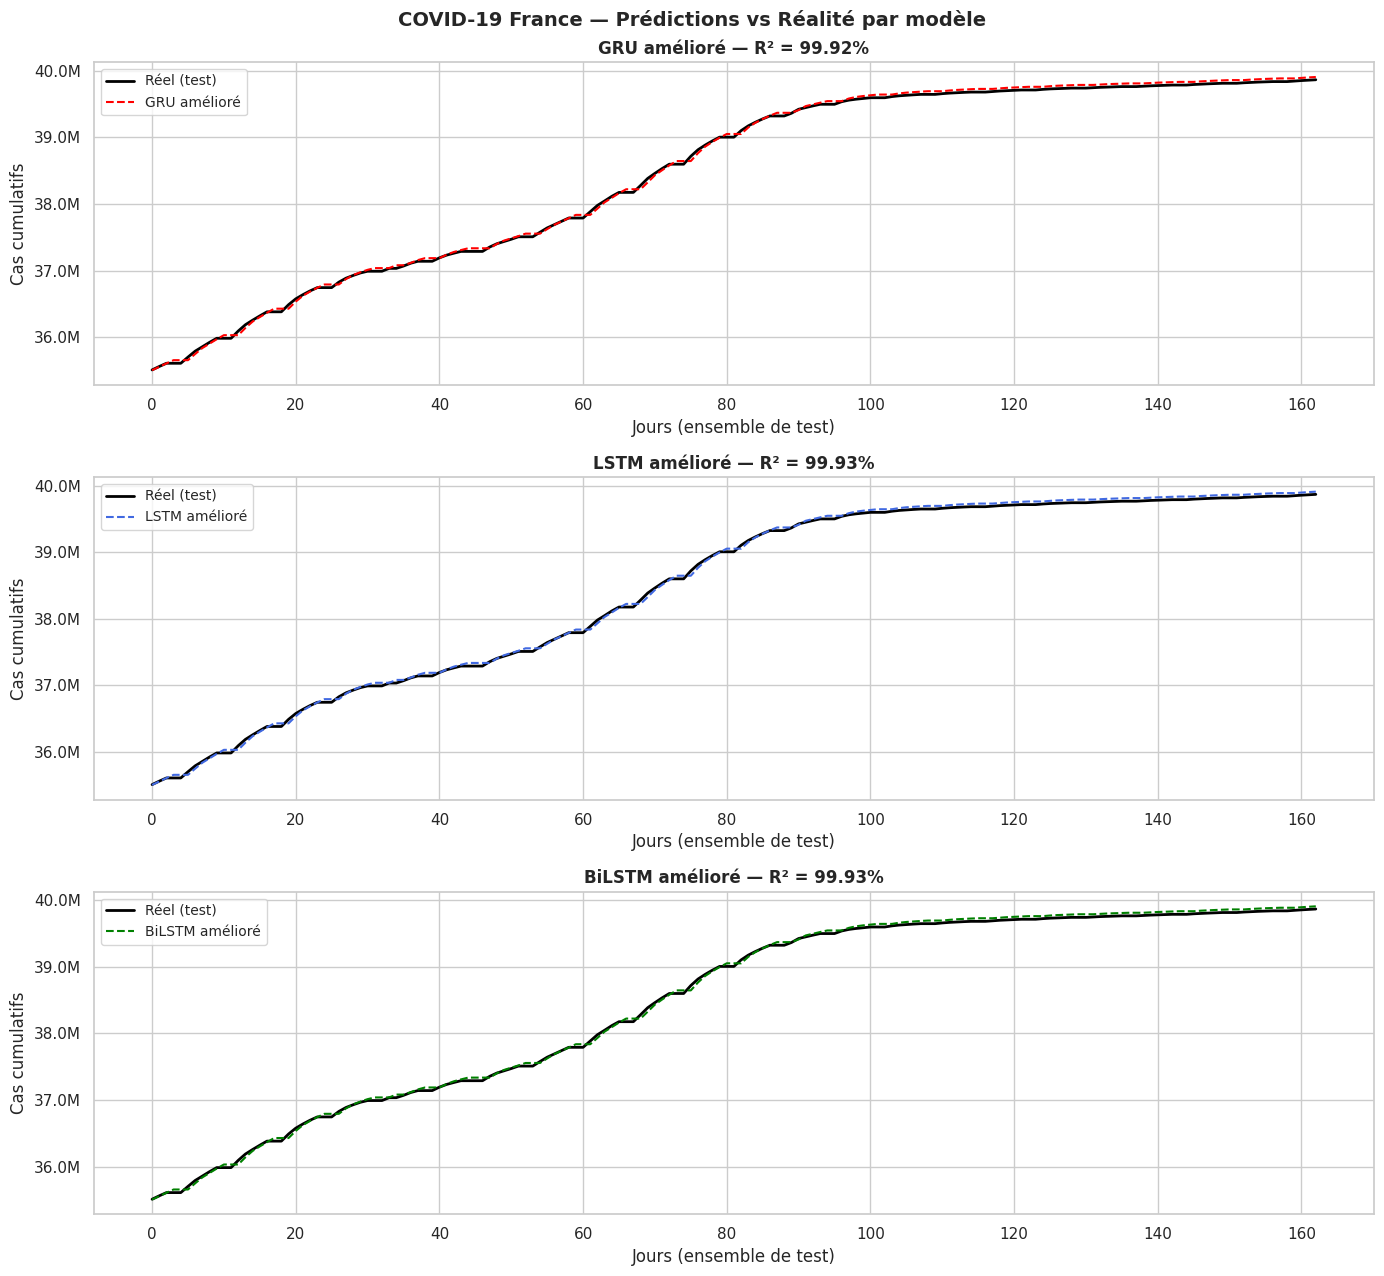

✅ Figure sauvegardée : fig_predictions_individuelles.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

plot_configs = [
    ("GRU amélioré",    gru_preds2,   true_vals2,   "red"),
    ("LSTM amélioré",   lstm_preds2,  true_vals2,   "royalblue"),
    ("BiLSTM amélioré", bilstm_preds, true_vals_bi, "green"),
]

for ax, (name, preds, trues, color) in zip(axes, plot_configs):
    r2_val = r2_score(trues, preds) * 100
    ax.plot(trues, label='Réel (test)',   color='black', lw=2.0)
    ax.plot(preds, label=f'{name}',       color=color,   lw=1.5, linestyle='--')
    ax.set_title(f"{name} — R² = {r2_val:.2f}%", fontsize=12, fontweight='bold')
    ax.set_xlabel("Jours (ensemble de test)"); ax.set_ylabel("Cas cumulatifs")
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("COVID-19 France — Prédictions vs Réalité par modèle",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_predictions_individuelles.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_predictions_individuelles.png")

## 15. Comparaison globale — GRU vs LSTM vs BiLSTM vs Réalité

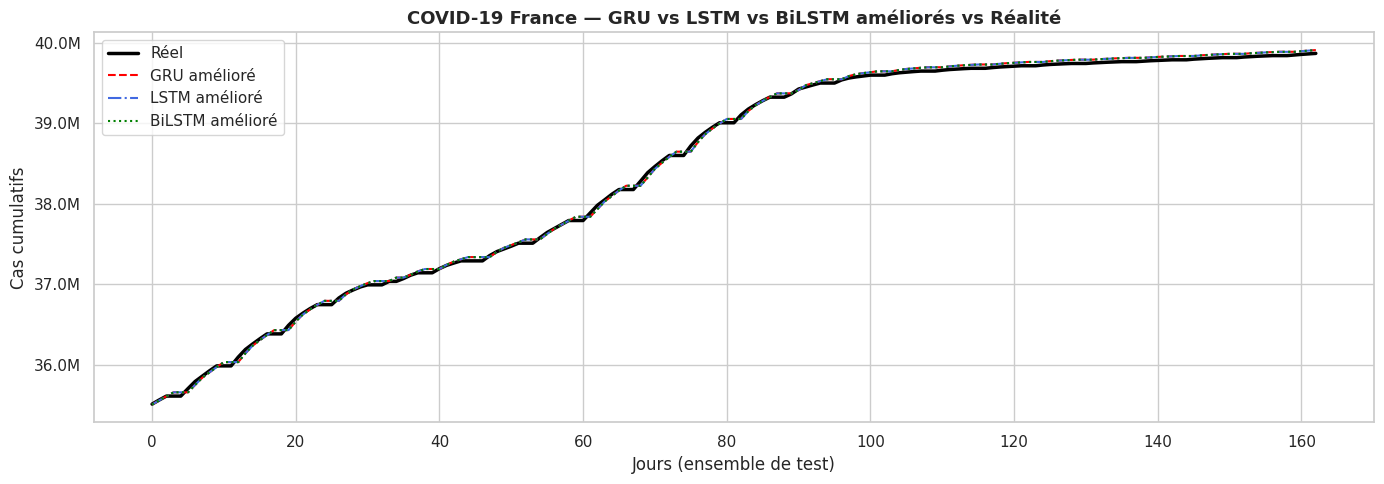

✅ Figure sauvegardée : fig_cumulatifs_gru_bilstm_ameliore.png


In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(true_vals2,   label='Réel',            color='black',     lw=2.5)
plt.plot(gru_preds2,   label='GRU amélioré',    color='red',       lw=1.5, linestyle='--')
plt.plot(lstm_preds2,  label='LSTM amélioré',   color='royalblue', lw=1.5, linestyle='-.')
plt.plot(bilstm_preds, label='BiLSTM amélioré', color='green',     lw=1.5, linestyle=':')

plt.title("COVID-19 France — GRU vs LSTM vs BiLSTM améliorés vs Réalité",
          fontsize=13, fontweight='bold')
plt.xlabel("Jours (ensemble de test)")
plt.ylabel("Cas cumulatifs")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("fig_cumulatifs_gru_bilstm_ameliore.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_cumulatifs_gru_bilstm_ameliore.png")

## 16. Résumé et conclusion

In [ ]:
print("\n" + "="*52)
print("   RÉSULTATS PRINCIPAUX DU NOTEBOOK")
print("="*52)

final_results = [
    ("GRU amélioré",    gru_preds2,   true_vals2),
    ("LSTM amélioré",   lstm_preds2,  true_vals2),
    ("BiLSTM amélioré", bilstm_preds, true_vals_bi),
]

best_model = None
best_r2    = -np.inf

for name, preds, trues in final_results:
    p_n    = scaler2.transform(preds)
    t_n    = scaler2.transform(trues)
    mae_n  = mean_absolute_error(t_n, p_n)
    rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
    mae_r  = mean_absolute_error(trues, preds)
    rmse_r = np.sqrt(mean_squared_error(trues, preds))
    r2_val = r2_score(trues, preds)
    print(f"\n  {name}")
    print(f"    MAE  normalisé : {mae_n:.6f}")
    print(f"    RMSE normalisé : {rmse_n:.6f}")
    print(f"    MAE  réel      : {mae_r:>15,.2f}")
    print(f"    RMSE réel      : {rmse_r:>15,.2f}")
    print(f"    R²             : {r2_val*100:.2f}%")
    if r2_val > best_r2:
        best_r2    = r2_val
        best_model = name

print("\n" + "="*52)
print(f"  ✅ Meilleur modèle retenu : {best_model}")
print(f"     R² = {best_r2*100:.2f}%")
print("="*52)


   RÉSULTATS PRINCIPAUX DU NOTEBOOK

  GRU amélioré
    MAE  normalisé : 0.000868
    RMSE normalisé : 0.000959
    MAE  réel      :       34,622.41
    RMSE réel      :       38,248.67
    R²             : 99.92%

  LSTM amélioré
    MAE  normalisé : 0.000861
    RMSE normalisé : 0.000952
    MAE  réel      :       34,338.48
    RMSE réel      :       37,935.75
    R²             : 99.93%

  BiLSTM amélioré
    MAE  normalisé : 0.000858
    RMSE normalisé : 0.000947
    MAE  réel      :       34,200.61
    RMSE réel      :       37,757.45
    R²             : 99.93%

  ✅ Meilleur modèle retenu : BiLSTM amélioré
     R² = 99.93%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

---
# 🇨🇳 PARTIE 2 — Prédiction COVID-19 : Chine (China)

Même pipeline que la France : prétraitement, GRU amélioré, LSTM amélioré, BiLSTM amélioré.

## 17. Prétraitement — Cas cumulatifs confirmés en Chine

In [ ]:
COUNTRY_CN = 'China'
SEQ_LEN_CN = 60

# Extraction Chine (somme de toutes les provinces)
df_target_cn = (df[df['Country/Region'] == COUNTRY_CN]
                .groupby('Date')[['Confirmed', 'Deaths', 'Recovered']]
                .sum()
                .reset_index()
                .sort_values('Date'))

df_target_cn['Daily_Confirmed'] = (df_target_cn['Confirmed']
                                    .diff().fillna(0).clip(lower=0))

print("✅ Données Chine extraites :", df_target_cn.shape)
print(df_target_cn[['Date','Confirmed','Daily_Confirmed']].tail(5))

✅ Données Chine extraites : (1143, 5)
           Date  Confirmed  Daily_Confirmed
1138 2023-03-05    4903524              0.0
1139 2023-03-06    4903524              0.0
1140 2023-03-07    4903524              0.0
1141 2023-03-08    4903524              0.0
1142 2023-03-09    4903524              0.0


### 17.1 Visualisation des cas — Chine

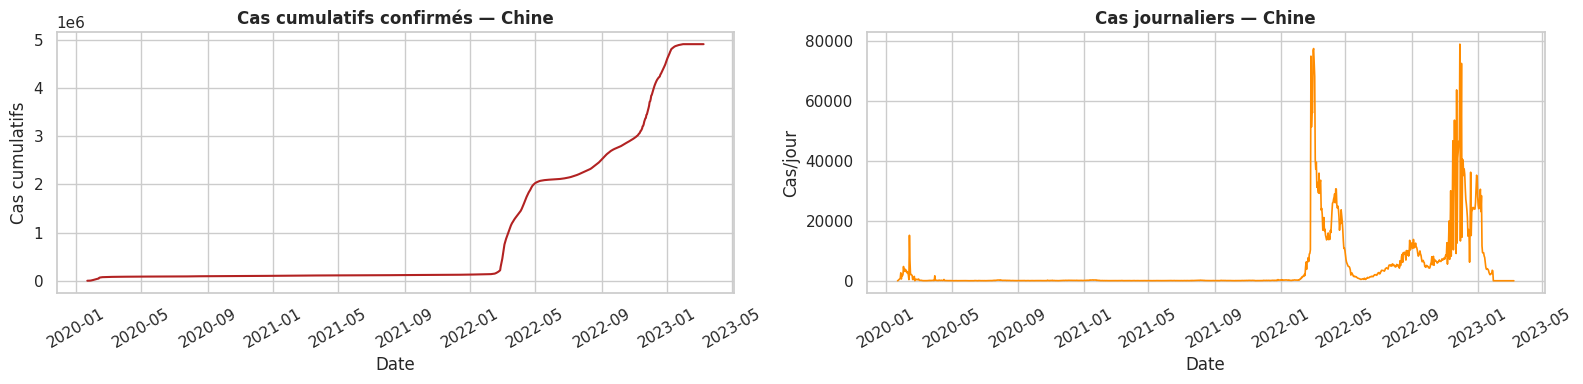

✅ Figure sauvegardée : fig_cas_chine.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df_target_cn['Date'], df_target_cn['Confirmed'],
             color='firebrick', lw=1.5)
axes[0].set_title("Cas cumulatifs confirmés — Chine", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(df_target_cn['Date'], df_target_cn['Daily_Confirmed'],
             color='darkorange', lw=1.2)
axes[1].set_title("Cas journaliers — Chine", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Cas/jour")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("fig_cas_chine.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_cas_chine.png")

### 17.2 Normalisation et séquences — Chine

In [ ]:
scaler_cn = MinMaxScaler()
data_scaled_cn = scaler_cn.fit_transform(df_target_cn[['Confirmed']])

X_cn, y_cn = [], []
for i in range(len(data_scaled_cn) - SEQ_LEN_CN):
    X_cn.append(data_scaled_cn[i : i + SEQ_LEN_CN])
    y_cn.append(data_scaled_cn[i + SEQ_LEN_CN])
X_cn, y_cn = np.array(X_cn), np.array(y_cn)

n_cn = len(X_cn)
X_train_cn = torch.FloatTensor(X_cn[:int(n_cn*0.70)])
y_train_cn = torch.FloatTensor(y_cn[:int(n_cn*0.70)])
X_val_cn   = torch.FloatTensor(X_cn[int(n_cn*0.70):int(n_cn*0.85)])
y_val_cn   = torch.FloatTensor(y_cn[int(n_cn*0.70):int(n_cn*0.85)])
X_test_cn  = torch.FloatTensor(X_cn[int(n_cn*0.85):])
y_test_cn  = torch.FloatTensor(y_cn[int(n_cn*0.85):])

print(f"Séquences totales : {n_cn}")
print(f"Train : {X_train_cn.shape} | Val : {X_val_cn.shape} | Test : {X_test_cn.shape}")

Séquences totales : 1083
Train : torch.Size([758, 60, 1]) | Val : torch.Size([162, 60, 1]) | Test : torch.Size([163, 60, 1])


### 17.3 Fonction d'évaluation — Chine

In [ ]:
def evaluate_cn(model, Xt, yt, name):
    return evaluate2(model, Xt, yt, name, scaler=scaler_cn)

print("✅ evaluate_cn définie")

✅ evaluate_cn définie


## 18. GRU amélioré — Chine

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

gru_cn = GRUAmeliore()   # même architecture que France
print(f"GRU amélioré (Chine) — Paramètres : {sum(p.numel() for p in gru_cn.parameters()):,}")

print("\n=== Entraînement GRU amélioré — Chine ===")
gru_tl_cn, gru_vl_cn = train_ameliore(
    gru_cn, X_train_cn, y_train_cn, X_val_cn, y_val_cn, epochs=700
)

GRU amélioré (Chine) — Paramètres : 157,697

=== Entraînement GRU amélioré — Chine ===
Epoch   50 | Train: 0.000003 | Val: 0.000002
Epoch  100 | Train: 0.000002 | Val: 0.000055
  ⏹ Early stopping à epoch 143
  ✅ Meilleur Val Loss : 0.000001


## 19. LSTM amélioré — Chine

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

lstm_cn = LSTMAmeliore()
print(f"LSTM amélioré (Chine) — Paramètres : {sum(p.numel() for p in lstm_cn.parameters()):,}")

print("\n=== Entraînement LSTM amélioré — Chine ===")
lstm_tl_cn, lstm_vl_cn = train_ameliore(
    lstm_cn, X_train_cn, y_train_cn, X_val_cn, y_val_cn, epochs=700
)

LSTM amélioré (Chine) — Paramètres : 207,489

=== Entraînement LSTM amélioré — Chine ===
Epoch   50 | Train: 0.000003 | Val: 0.000001
Epoch  100 | Train: 0.000003 | Val: 0.000001
  ⏹ Early stopping à epoch 107
  ✅ Meilleur Val Loss : 0.000001


## 20. BiLSTM amélioré — Chine

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

bilstm_cn = BiLSTMAmeliore()
print(f"BiLSTM amélioré (Chine) — Paramètres : {sum(p.numel() for p in bilstm_cn.parameters()):,}")

print("\n=== Entraînement BiLSTM amélioré — Chine ===")
bilstm_tl_cn, bilstm_vl_cn = train_ameliore(
    bilstm_cn, X_train_cn, y_train_cn, X_val_cn, y_val_cn, epochs=700
)

BiLSTM amélioré (Chine) — Paramètres : 545,921

=== Entraînement BiLSTM amélioré — Chine ===
Epoch   50 | Train: 0.000003 | Val: 0.000001
Epoch  100 | Train: 0.000003 | Val: 0.000001
  ⏹ Early stopping à epoch 109
  ✅ Meilleur Val Loss : 0.000001


## 21. Courbes d'apprentissage — Chine

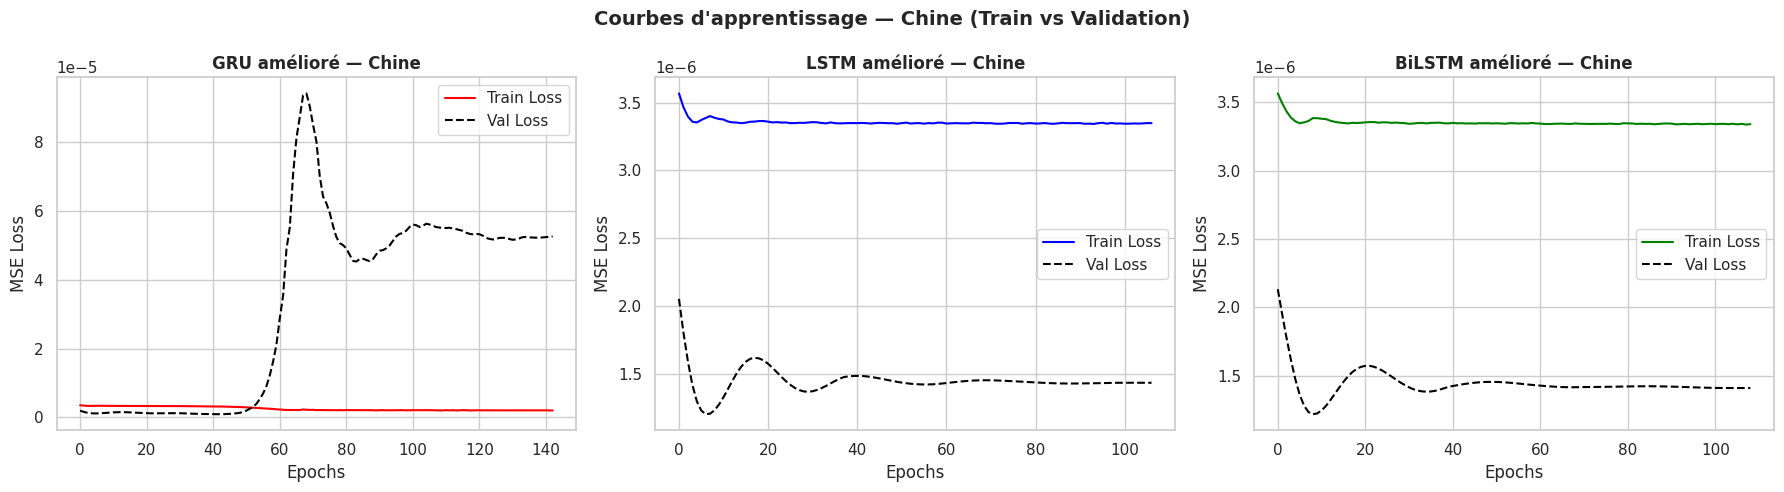

✅ Figure sauvegardée : fig_loss_chine.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_cn = [
    (gru_tl_cn,    gru_vl_cn,    "GRU amélioré",    "red"),
    (lstm_tl_cn,   lstm_vl_cn,   "LSTM amélioré",   "blue"),
    (bilstm_tl_cn, bilstm_vl_cn, "BiLSTM amélioré", "green"),
]

for ax, (tl, vl, name, color) in zip(axes, configs_cn):
    ax.plot(tl, label='Train Loss', color=color,   lw=1.5)
    ax.plot(vl, label='Val Loss',   color='black', lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Chine", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epochs"); ax.set_ylabel("MSE Loss")
    ax.legend()

plt.suptitle("Courbes d'apprentissage — Chine (Train vs Validation)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_loss_chine.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_loss_chine.png")

## 22. Évaluation sur l'ensemble de test — Chine

In [ ]:
print("\n" + "="*52)
print("   ÉVALUATION COMPLÈTE — CHINE")
print("="*52)

gru_preds_cn,   true_cn   = evaluate_cn(gru_cn,    X_test_cn, y_test_cn, "GRU amélioré")
lstm_preds_cn,  _         = evaluate_cn(lstm_cn,   X_test_cn, y_test_cn, "LSTM amélioré")
bilstm_preds_cn, true_bi_cn = evaluate_cn(bilstm_cn, X_test_cn, y_test_cn, "BiLSTM amélioré")


   ÉVALUATION COMPLÈTE — CHINE

  GRU amélioré
  MAE  normalisé  : 0.002273
  RMSE normalisé  : 0.003343
  ─────────────────────────────────────
  MAE  réel       :          11,142.60  cas
  RMSE réel       :          16,392.81  cas
  ─────────────────────────────────────
  R²              : 0.9996  (99.96%)

  LSTM amélioré
  MAE  normalisé  : 0.002368
  RMSE normalisé  : 0.003729
  ─────────────────────────────────────
  MAE  réel       :          11,609.98  cas
  RMSE réel       :          18,282.13  cas
  ─────────────────────────────────────
  R²              : 0.9995  (99.95%)

  BiLSTM amélioré
  MAE  normalisé  : 0.002373
  RMSE normalisé  : 0.003734
  ─────────────────────────────────────
  MAE  réel       :          11,635.70  cas
  RMSE réel       :          18,307.59  cas
  ─────────────────────────────────────
  R²              : 0.9995  (99.95%)


## 23. Tableau comparatif — Chine

In [ ]:
print("\n" + "="*70)
print(f"  {'Modèle':<22} {'MAE norm':>11}  {'RMSE norm':>11}  {'R²':>10}")
print("="*70)

results_cn = [
    ("GRU amélioré",    gru_preds_cn,    true_cn),
    ("LSTM amélioré",   lstm_preds_cn,   true_cn),
    ("BiLSTM amélioré", bilstm_preds_cn, true_bi_cn),
]

best_r2_cn   = -np.inf
best_name_cn = ""

for name, preds, trues in results_cn:
    p_n    = scaler_cn.transform(preds)
    t_n    = scaler_cn.transform(trues)
    mae_n  = mean_absolute_error(t_n, p_n)
    rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
    r2_val = r2_score(trues, preds) * 100
    print(f"  {name:<22} {mae_n:>11.6f}  {rmse_n:>11.6f}  {r2_val:>9.2f}%")
    if r2_val > best_r2_cn:
        best_r2_cn   = r2_val
        best_name_cn = name

print("="*70)
print(f"  🏆 Meilleur modèle (Chine) : {best_name_cn}  (R² = {best_r2_cn:.2f}%)")
print("="*70)


  Modèle                    MAE norm    RMSE norm          R²
  GRU amélioré              0.002273     0.003343      99.96%
  LSTM amélioré             0.002368     0.003729      99.95%
  BiLSTM amélioré           0.002373     0.003734      99.95%
  🏆 Meilleur modèle (Chine) : GRU amélioré  (R² = 99.96%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

## 24. Prédictions vs Réalité — Chine

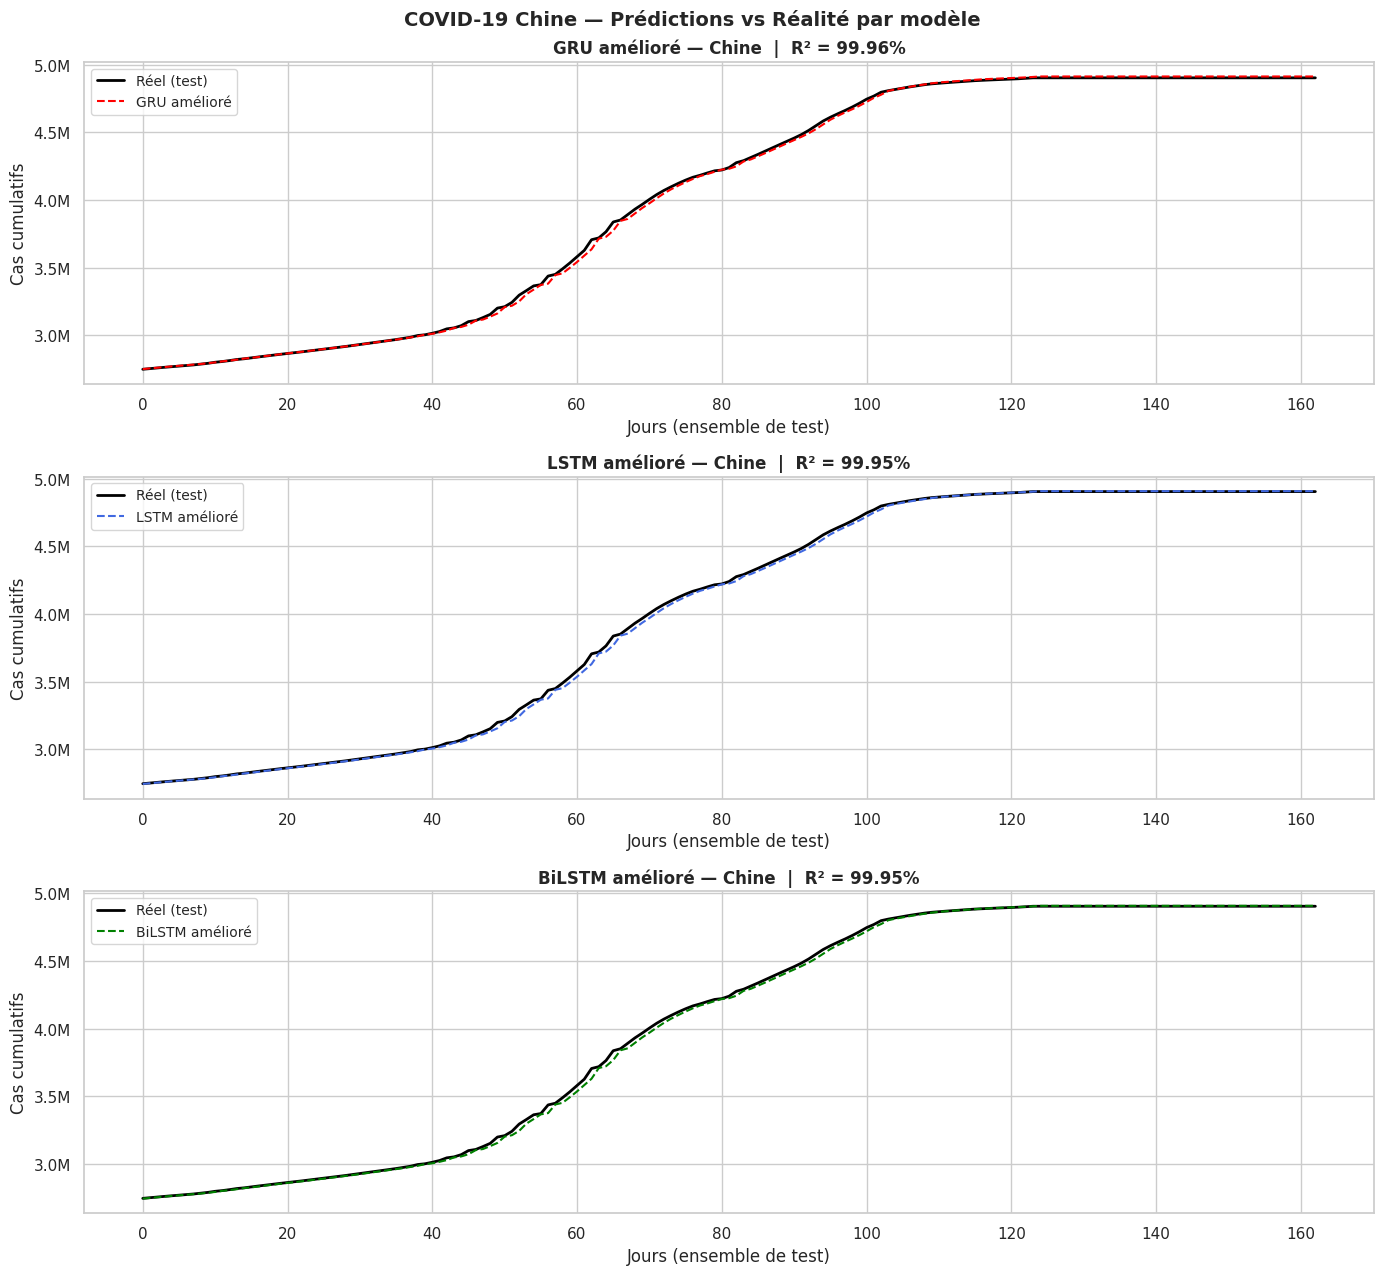

✅ Figure sauvegardée : fig_predictions_chine.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

plot_cn = [
    ("GRU amélioré",    gru_preds_cn,    true_cn,    "red"),
    ("LSTM amélioré",   lstm_preds_cn,   true_cn,    "royalblue"),
    ("BiLSTM amélioré", bilstm_preds_cn, true_bi_cn, "green"),
]

for ax, (name, preds, trues, color) in zip(axes, plot_cn):
    r2_val = r2_score(trues, preds) * 100
    ax.plot(trues, label='Réel (test)',  color='black', lw=2.0)
    ax.plot(preds, label=f'{name}',      color=color,   lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Chine  |  R² = {r2_val:.2f}%",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Jours (ensemble de test)")
    ax.set_ylabel("Cas cumulatifs")
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("COVID-19 Chine — Prédictions vs Réalité par modèle",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_predictions_chine.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_predictions_chine.png")

## 25. Comparaison globale — Chine

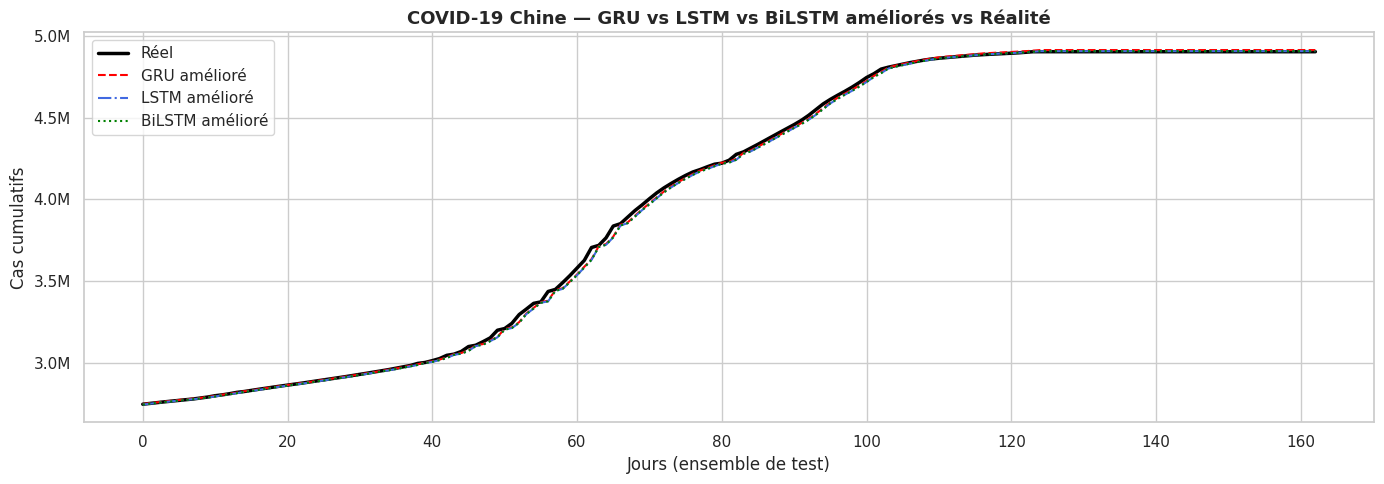

✅ Figure sauvegardée : fig_comparaison_chine.png


In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(true_cn,        label='Réel',            color='black',     lw=2.5)
plt.plot(gru_preds_cn,   label='GRU amélioré',    color='red',       lw=1.5, linestyle='--')
plt.plot(lstm_preds_cn,  label='LSTM amélioré',   color='royalblue', lw=1.5, linestyle='-.')
plt.plot(bilstm_preds_cn,label='BiLSTM amélioré', color='green',     lw=1.5, linestyle=':')

plt.title("COVID-19 Chine — GRU vs LSTM vs BiLSTM améliorés vs Réalité",
          fontsize=13, fontweight='bold')
plt.xlabel("Jours (ensemble de test)")
plt.ylabel("Cas cumulatifs")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("fig_comparaison_chine.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_comparaison_chine.png")

## 26. Comparaison France 🇫🇷 vs Chine 🇨🇳 — Meilleur modèle (BiLSTM amélioré)

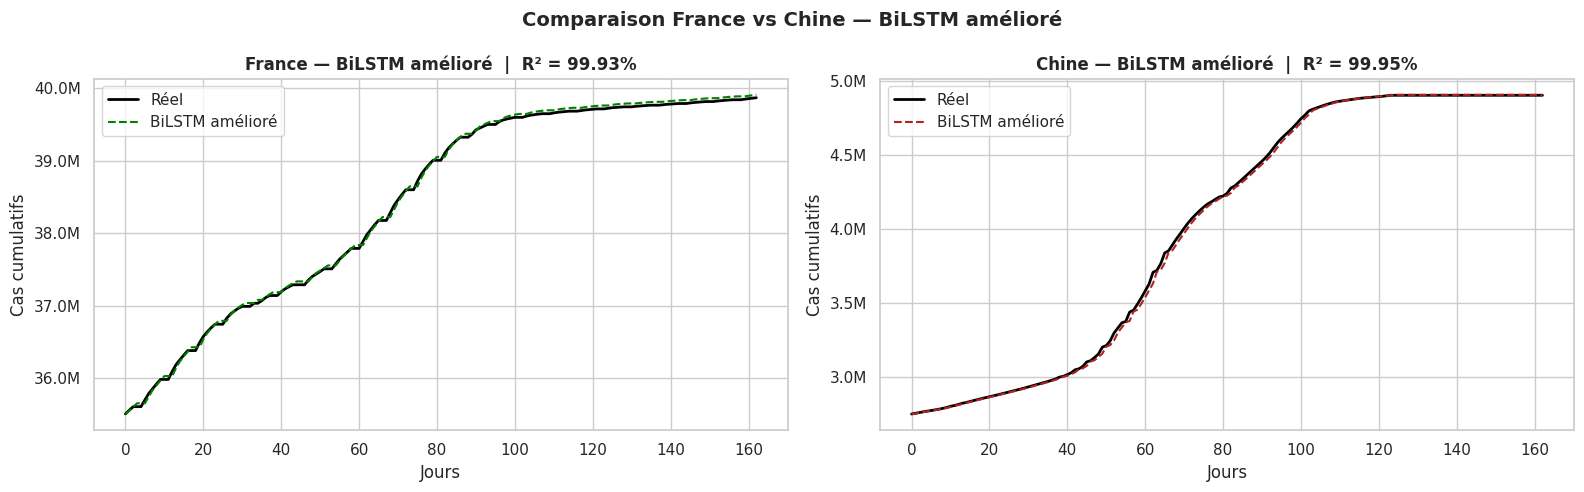

✅ Figure sauvegardée : fig_france_vs_chine.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# France
r2_fr = r2_score(true_vals_bi, bilstm_preds) * 100
axes[0].plot(true_vals_bi, label='Réel',            color='black', lw=2)
axes[0].plot(bilstm_preds, label='BiLSTM amélioré', color='green', lw=1.5, linestyle='--')
axes[0].set_title(f"France — BiLSTM amélioré  |  R² = {r2_fr:.2f}%",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Jours"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Chine
r2_cn = r2_score(true_bi_cn, bilstm_preds_cn) * 100
axes[1].plot(true_bi_cn,      label='Réel',            color='black',    lw=2)
axes[1].plot(bilstm_preds_cn, label='BiLSTM amélioré', color='firebrick',lw=1.5, linestyle='--')
axes[1].set_title(f"Chine — BiLSTM amélioré  |  R² = {r2_cn:.2f}%",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Jours"); axes[1].set_ylabel("Cas cumulatifs")
axes[1].legend()
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("Comparaison France vs Chine — BiLSTM amélioré",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_france_vs_chine.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : fig_france_vs_chine.png")

## 27. Résumé final — France + Chine

In [ ]:
print("\n" + "="*60)
print("   RÉSUMÉ FINAL — FRANCE & CHINE")
print("="*60)

all_results = {
    "France": [
        ("GRU amélioré",    gru_preds2,      true_vals2),
        ("LSTM amélioré",   lstm_preds2,     true_vals2),
        ("BiLSTM amélioré", bilstm_preds,    true_vals_bi),
    ],
    "Chine": [
        ("GRU amélioré",    gru_preds_cn,    true_cn),
        ("LSTM amélioré",   lstm_preds_cn,   true_cn),
        ("BiLSTM amélioré", bilstm_preds_cn, true_bi_cn),
    ],
}

for country, results in all_results.items():
    print(f"\n  {'─'*50}")
    print(f"  🌍 {country}")
    print(f"  {'─'*50}")
    sc = scaler2 if country == "France" else scaler_cn
    for name, preds, trues in results:
        p_n   = sc.transform(preds)
        t_n   = sc.transform(trues)
        mae_n = mean_absolute_error(t_n, p_n)
        rmse_n= np.sqrt(mean_squared_error(t_n, p_n))
        r2_v  = r2_score(trues, preds) * 100
        print(f"    {name:<22}  MAE={mae_n:.6f}  RMSE={rmse_n:.6f}  R²={r2_v:.2f}%")

print("\n" + "="*60)


   RÉSUMÉ FINAL — FRANCE & CHINE

  ──────────────────────────────────────────────────
  🌍 France
  ──────────────────────────────────────────────────
    GRU amélioré            MAE=0.000868  RMSE=0.000959  R²=99.92%
    LSTM amélioré           MAE=0.000861  RMSE=0.000952  R²=99.93%
    BiLSTM amélioré         MAE=0.000858  RMSE=0.000947  R²=99.93%

  ──────────────────────────────────────────────────
  🌍 Chine
  ──────────────────────────────────────────────────
    GRU amélioré            MAE=0.002273  RMSE=0.003343  R²=99.96%
    LSTM amélioré           MAE=0.002368  RMSE=0.003729  R²=99.95%
    BiLSTM amélioré         MAE=0.002373  RMSE=0.003734  R²=99.95%



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

---
# 🇨🇳 PARTIE 2 — Prédiction COVID-19 : Chine (China)

Même pipeline que la France : prétraitement, GRU amélioré, LSTM amélioré, BiLSTM amélioré.

## 17. Prétraitement — Cas cumulatifs confirmés en Chine

In [ ]:
COUNTRY_CN = 'China'
SEQ_LEN_CN = 60

# Extraction et tri Chine
df_china = (df[df['Country/Region'] == COUNTRY_CN]
            .groupby('Date')[['Confirmed', 'Deaths', 'Recovered']]
            .sum()
            .reset_index()
            .sort_values('Date'))

df_china['Daily_Confirmed'] = df_china['Confirmed'].diff().fillna(0).clip(lower=0)

print("✅ Données Chine extraites :", df_china.shape)
print(df_china[['Date','Confirmed','Daily_Confirmed']].tail(5))

✅ Données Chine extraites : (1143, 5)
           Date  Confirmed  Daily_Confirmed
1138 2023-03-05    4903524              0.0
1139 2023-03-06    4903524              0.0
1140 2023-03-07    4903524              0.0
1141 2023-03-08    4903524              0.0
1142 2023-03-09    4903524              0.0


### 17.1 Visualisation — Cas cumulatifs et journaliers en Chine

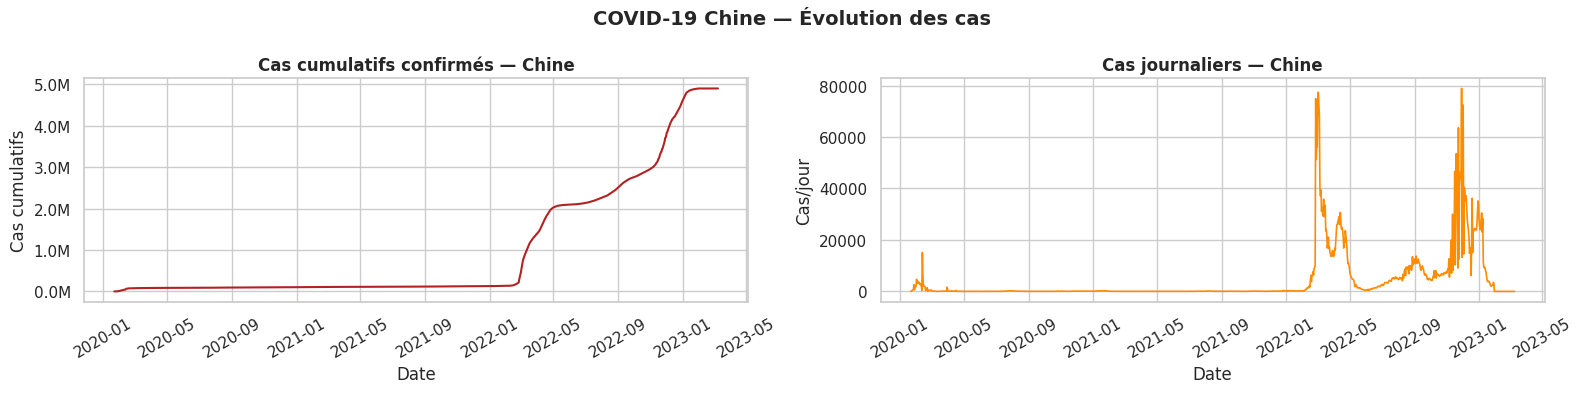

✅ fig_china_cas.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df_china['Date'], df_china['Confirmed'],
             color='firebrick', lw=1.5)
axes[0].set_title("Cas cumulatifs confirmés — Chine", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].plot(df_china['Date'], df_china['Daily_Confirmed'],
             color='darkorange', lw=1.2)
axes[1].set_title("Cas journaliers — Chine", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Cas/jour")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("COVID-19 Chine — Évolution des cas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_china_cas.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_china_cas.png sauvegardée")

### 17.2 Normalisation et création des séquences

In [ ]:
scaler_cn = MinMaxScaler()
data_scaled_cn = scaler_cn.fit_transform(df_china[['Confirmed']])

X_cn, y_cn = [], []
for i in range(len(data_scaled_cn) - SEQ_LEN_CN):
    X_cn.append(data_scaled_cn[i : i + SEQ_LEN_CN])
    y_cn.append(data_scaled_cn[i + SEQ_LEN_CN])
X_cn, y_cn = np.array(X_cn), np.array(y_cn)

n_cn = len(X_cn)
X_train_cn = torch.FloatTensor(X_cn[:int(n_cn*0.70)])
y_train_cn = torch.FloatTensor(y_cn[:int(n_cn*0.70)])
X_val_cn   = torch.FloatTensor(X_cn[int(n_cn*0.70):int(n_cn*0.85)])
y_val_cn   = torch.FloatTensor(y_cn[int(n_cn*0.70):int(n_cn*0.85)])
X_test_cn  = torch.FloatTensor(X_cn[int(n_cn*0.85):])
y_test_cn  = torch.FloatTensor(y_cn[int(n_cn*0.85):])

print(f"Séquences totales : {n_cn}")
print(f"Train : {X_train_cn.shape} | Val : {X_val_cn.shape} | Test : {X_test_cn.shape}")

Séquences totales : 1083
Train : torch.Size([758, 60, 1]) | Val : torch.Size([162, 60, 1]) | Test : torch.Size([163, 60, 1])


### 17.3 Fonction d'évaluation pour la Chine

In [ ]:
def evaluate_cn(model, Xt, yt, name):
    """Identique à evaluate2 mais utilise scaler_cn"""
    return evaluate2(model, Xt, yt, name, scaler=scaler_cn)

print("✅ evaluate_cn définie")

✅ evaluate_cn définie


## 18. GRU amélioré — Chine

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

gru_cn = GRUAmeliore()
print(f"GRU amélioré (Chine) — Paramètres : {sum(p.numel() for p in gru_cn.parameters()):,}")

print("\n=== Entraînement GRU amélioré — Chine ===")
gru_tl_cn, gru_vl_cn = train_ameliore(
    gru_cn, X_train_cn, y_train_cn, X_val_cn, y_val_cn, epochs=700
)

GRU amélioré (Chine) — Paramètres : 157,697

=== Entraînement GRU amélioré — Chine ===
Epoch   50 | Train: 0.000003 | Val: 0.000002
Epoch  100 | Train: 0.000002 | Val: 0.000055
  ⏹ Early stopping à epoch 143
  ✅ Meilleur Val Loss : 0.000001


## 19. LSTM amélioré — Chine

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

lstm_cn = LSTMAmeliore()
print(f"LSTM amélioré (Chine) — Paramètres : {sum(p.numel() for p in lstm_cn.parameters()):,}")

print("\n=== Entraînement LSTM amélioré — Chine ===")
lstm_tl_cn, lstm_vl_cn = train_ameliore(
    lstm_cn, X_train_cn, y_train_cn, X_val_cn, y_val_cn, epochs=700
)

LSTM amélioré (Chine) — Paramètres : 207,489

=== Entraînement LSTM amélioré — Chine ===
Epoch   50 | Train: 0.000003 | Val: 0.000001
Epoch  100 | Train: 0.000003 | Val: 0.000001
  ⏹ Early stopping à epoch 107
  ✅ Meilleur Val Loss : 0.000001


## 20. BiLSTM amélioré — Chine

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

bilstm_cn = BiLSTMAmeliore()
print(f"BiLSTM amélioré (Chine) — Paramètres : {sum(p.numel() for p in bilstm_cn.parameters()):,}")

print("\n=== Entraînement BiLSTM amélioré — Chine ===")
bilstm_tl_cn, bilstm_vl_cn = train_ameliore(
    bilstm_cn, X_train_cn, y_train_cn, X_val_cn, y_val_cn, epochs=700
)

BiLSTM amélioré (Chine) — Paramètres : 545,921

=== Entraînement BiLSTM amélioré — Chine ===
Epoch   50 | Train: 0.000003 | Val: 0.000001
Epoch  100 | Train: 0.000003 | Val: 0.000001
  ⏹ Early stopping à epoch 109
  ✅ Meilleur Val Loss : 0.000001


## 21. Courbes d'apprentissage — Chine

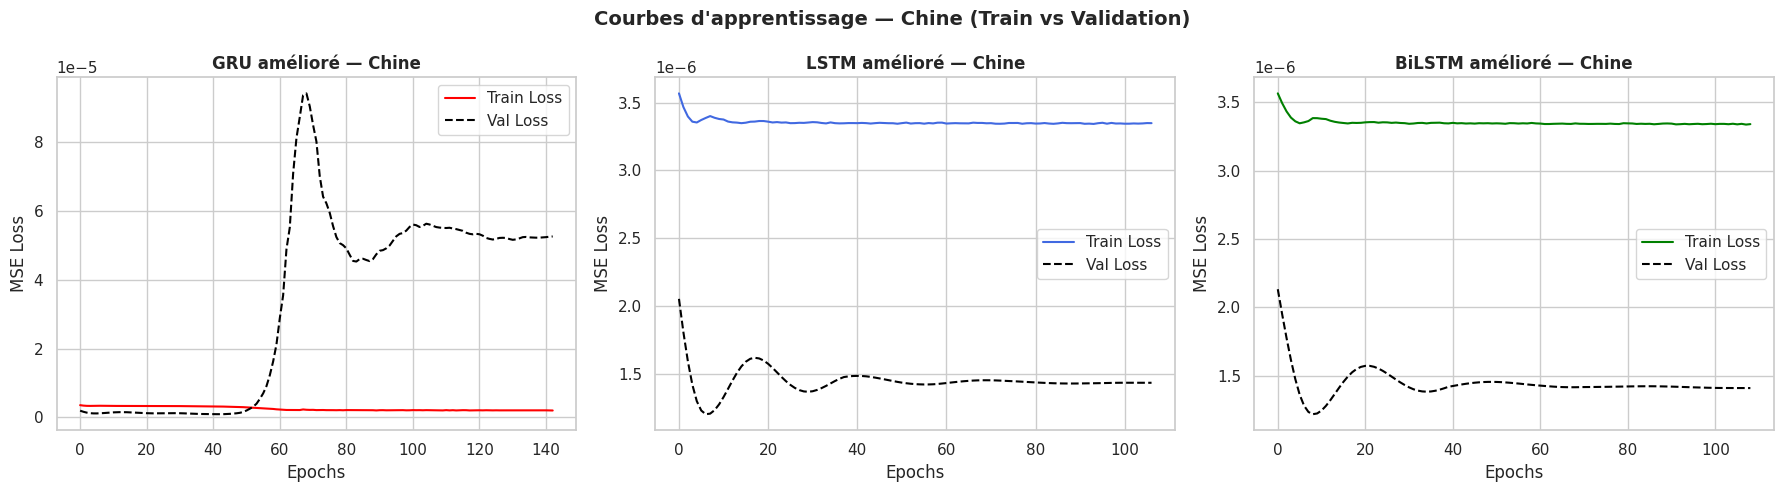

✅ fig_loss_china.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_cn = [
    (gru_tl_cn,    gru_vl_cn,    "GRU amélioré",    "red"),
    (lstm_tl_cn,   lstm_vl_cn,   "LSTM amélioré",   "royalblue"),
    (bilstm_tl_cn, bilstm_vl_cn, "BiLSTM amélioré", "green"),
]

for ax, (tl, vl, name, color) in zip(axes, configs_cn):
    ax.plot(tl, label='Train Loss', color=color,   lw=1.5)
    ax.plot(vl, label='Val Loss',   color='black', lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Chine", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epochs"); ax.set_ylabel("MSE Loss")
    ax.legend()

plt.suptitle("Courbes d'apprentissage — Chine (Train vs Validation)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_loss_china.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_loss_china.png sauvegardée")

## 22. Évaluation — Chine

In [ ]:
print("\n" + "="*52)
print("   ÉVALUATION DES MODÈLES — CHINE")
print("="*52)

gru_preds_cn,   true_cn   = evaluate_cn(gru_cn,    X_test_cn, y_test_cn, "GRU amélioré")
lstm_preds_cn,  _         = evaluate_cn(lstm_cn,   X_test_cn, y_test_cn, "LSTM amélioré")
bilstm_preds_cn, true_cn2 = evaluate_cn(bilstm_cn, X_test_cn, y_test_cn, "BiLSTM amélioré")


   ÉVALUATION DES MODÈLES — CHINE

  GRU amélioré
  MAE  normalisé  : 0.002273
  RMSE normalisé  : 0.003343
  ─────────────────────────────────────
  MAE  réel       :          11,142.60  cas
  RMSE réel       :          16,392.81  cas
  ─────────────────────────────────────
  R²              : 0.9996  (99.96%)

  LSTM amélioré
  MAE  normalisé  : 0.002368
  RMSE normalisé  : 0.003729
  ─────────────────────────────────────
  MAE  réel       :          11,609.98  cas
  RMSE réel       :          18,282.13  cas
  ─────────────────────────────────────
  R²              : 0.9995  (99.95%)

  BiLSTM amélioré
  MAE  normalisé  : 0.002373
  RMSE normalisé  : 0.003734
  ─────────────────────────────────────
  MAE  réel       :          11,635.70  cas
  RMSE réel       :          18,307.59  cas
  ─────────────────────────────────────
  R²              : 0.9995  (99.95%)


## 23. Tableau comparatif — Chine

In [ ]:
print("\n" + "="*70)
print(f"  {'Modèle':<22} {'MAE norm':>11}  {'RMSE norm':>11}  {'R²':>10}")
print("="*70)

results_cn = [
    ("GRU amélioré",    gru_preds_cn,    true_cn),
    ("LSTM amélioré",   lstm_preds_cn,   true_cn),
    ("BiLSTM amélioré", bilstm_preds_cn, true_cn2),
]

best_r2_cn   = -np.inf
best_name_cn = ""

for name, preds, trues in results_cn:
    p_n    = scaler_cn.transform(preds)
    t_n    = scaler_cn.transform(trues)
    mae_n  = mean_absolute_error(t_n, p_n)
    rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
    r2_val = r2_score(trues, preds) * 100
    print(f"  {name:<22} {mae_n:>11.6f}  {rmse_n:>11.6f}  {r2_val:>9.2f}%")
    if r2_val > best_r2_cn:
        best_r2_cn   = r2_val
        best_name_cn = name

print("="*70)
print(f"  🏆 Meilleur modèle (Chine) : {best_name_cn}  (R² = {best_r2_cn:.2f}%)")
print("="*70)


  Modèle                    MAE norm    RMSE norm          R²
  GRU amélioré              0.002273     0.003343      99.96%
  LSTM amélioré             0.002368     0.003729      99.95%
  BiLSTM amélioré           0.002373     0.003734      99.95%
  🏆 Meilleur modèle (Chine) : GRU amélioré  (R² = 99.96%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

## 24. Prédictions vs Réalité — Chine

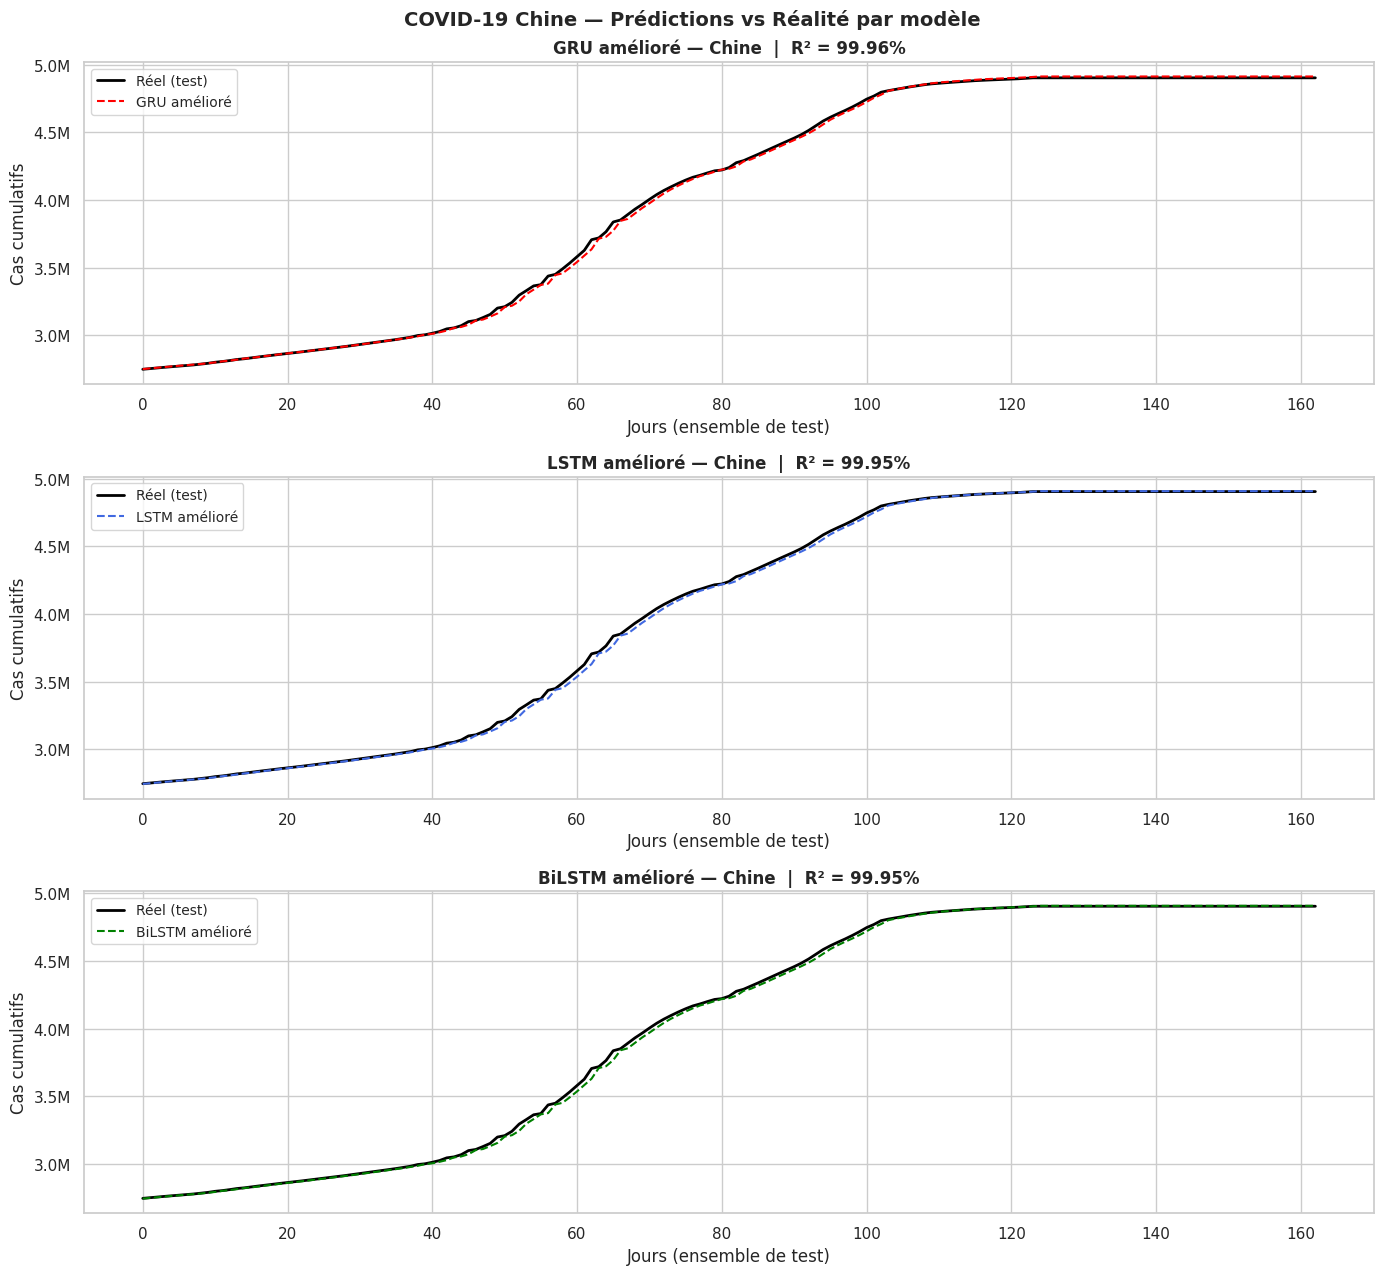

✅ fig_predictions_china.png sauvegardée


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

plot_cn = [
    ("GRU amélioré",    gru_preds_cn,    true_cn,  "red"),
    ("LSTM amélioré",   lstm_preds_cn,   true_cn,  "royalblue"),
    ("BiLSTM amélioré", bilstm_preds_cn, true_cn2, "green"),
]

for ax, (name, preds, trues, color) in zip(axes, plot_cn):
    r2_val = r2_score(trues, preds) * 100
    ax.plot(trues, label='Réel (test)',  color='black', lw=2.0)
    ax.plot(preds, label=f'{name}',      color=color,   lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Chine  |  R² = {r2_val:.2f}%",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Jours (ensemble de test)")
    ax.set_ylabel("Cas cumulatifs")
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("COVID-19 Chine — Prédictions vs Réalité par modèle",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_predictions_china.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_predictions_china.png sauvegardée")

## 25. Comparaison globale — Chine

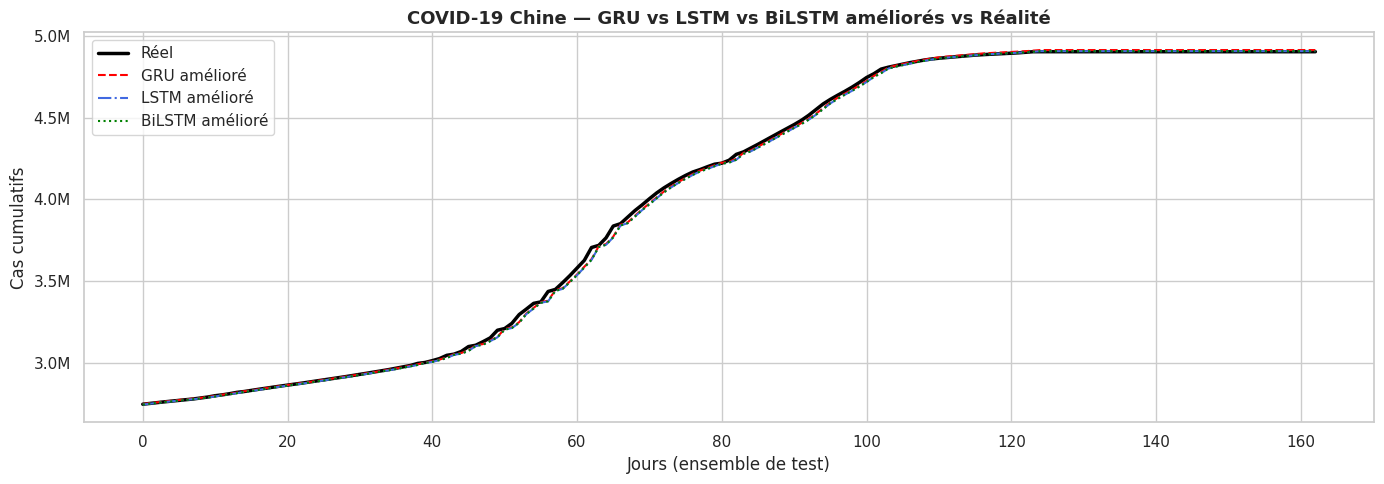

✅ fig_comparaison_china.png sauvegardée


In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(true_cn,         label='Réel',            color='black',     lw=2.5)
plt.plot(gru_preds_cn,    label='GRU amélioré',    color='red',       lw=1.5, linestyle='--')
plt.plot(lstm_preds_cn,   label='LSTM amélioré',   color='royalblue', lw=1.5, linestyle='-.')
plt.plot(bilstm_preds_cn, label='BiLSTM amélioré', color='green',     lw=1.5, linestyle=':')

plt.title("COVID-19 Chine — GRU vs LSTM vs BiLSTM améliorés vs Réalité",
          fontsize=13, fontweight='bold')
plt.xlabel("Jours (ensemble de test)")
plt.ylabel("Cas cumulatifs")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("fig_comparaison_china.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_comparaison_china.png sauvegardée")

## 26. Comparaison France 🇫🇷 vs Chine 🇨🇳 — Meilleur modèle (BiLSTM)

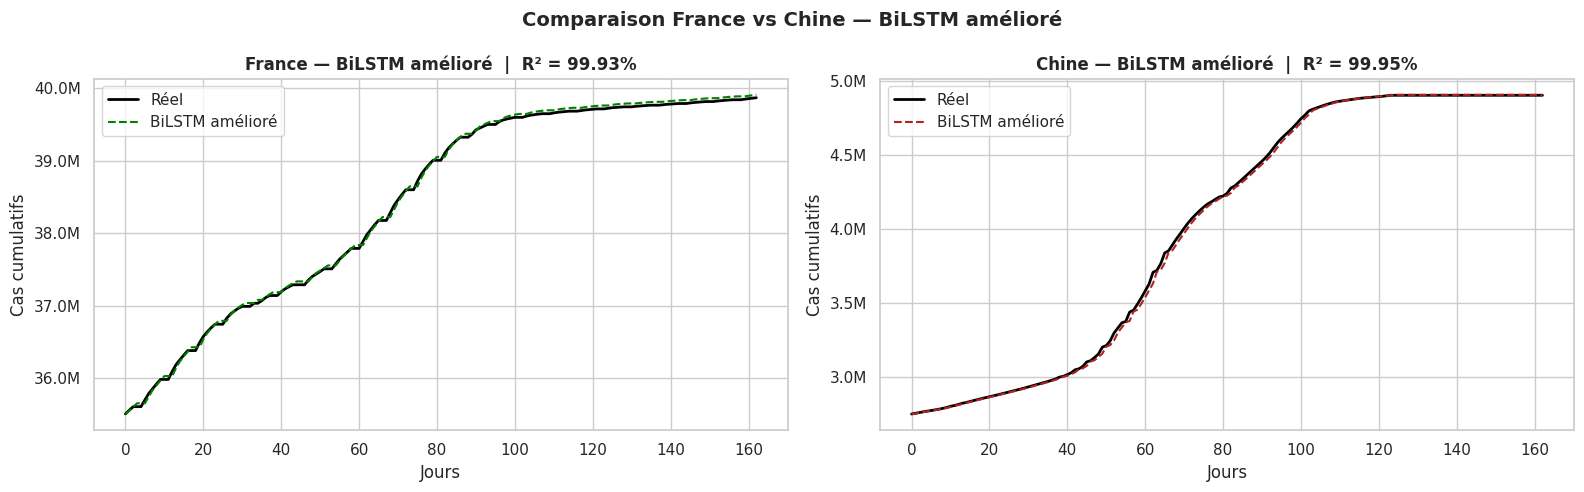

✅ fig_france_vs_china.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# France
r2_fr = r2_score(true_vals_bi, bilstm_preds) * 100
axes[0].plot(true_vals_bi, label='Réel',           color='black', lw=2)
axes[0].plot(bilstm_preds, label='BiLSTM amélioré',color='green', lw=1.5, linestyle='--')
axes[0].set_title(f"France — BiLSTM amélioré  |  R² = {r2_fr:.2f}%",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Jours"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].legend(); axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Chine
r2_cn_bi = r2_score(true_cn2, bilstm_preds_cn) * 100
axes[1].plot(true_cn2,       label='Réel',           color='black',   lw=2)
axes[1].plot(bilstm_preds_cn,label='BiLSTM amélioré',color='firebrick',lw=1.5, linestyle='--')
axes[1].set_title(f"Chine — BiLSTM amélioré  |  R² = {r2_cn_bi:.2f}%",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Jours"); axes[1].set_ylabel("Cas cumulatifs")
axes[1].legend(); axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("Comparaison France vs Chine — BiLSTM amélioré",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_france_vs_china.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_france_vs_china.png sauvegardée")

## 27. Résumé final — France et Chine

In [ ]:
print("\n" + "="*65)
print("   RÉSUMÉ COMPARATIF FINAL — FRANCE & CHINE")
print("="*65)

all_results = {
    "France": [
        ("GRU amélioré",    gru_preds2,      true_vals2),
        ("LSTM amélioré",   lstm_preds2,     true_vals2),
        ("BiLSTM amélioré", bilstm_preds,    true_vals_bi),
    ],
    "Chine": [
        ("GRU amélioré",    gru_preds_cn,    true_cn),
        ("LSTM amélioré",   lstm_preds_cn,   true_cn),
        ("BiLSTM amélioré", bilstm_preds_cn, true_cn2),
    ],
}

scalers = {"France": scaler2, "Chine": scaler_cn}

for country, results in all_results.items():
    sc = scalers[country]
    print(f"\n  {'─'*55}")
    print(f"  Pays : {country}")
    print(f"  {'─'*55}")
    print(f"  {'Modèle':<22} {'MAE norm':>10}  {'RMSE norm':>10}  {'R²':>8}")
    best_r2_c = -np.inf
    best_name_c = ""
    for name, preds, trues in results:
        p_n    = sc.transform(preds)
        t_n    = sc.transform(trues)
        mae_n  = mean_absolute_error(t_n, p_n)
        rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
        r2_val = r2_score(trues, preds) * 100
        print(f"  {name:<22} {mae_n:>10.6f}  {rmse_n:>10.6f}  {r2_val:>7.2f}%")
        if r2_val > best_r2_c:
            best_r2_c   = r2_val
            best_name_c = name
    print(f"  🏆 Meilleur : {best_name_c}  (R² = {best_r2_c:.2f}%)")

print("\n" + "="*65)


   RÉSUMÉ COMPARATIF FINAL — FRANCE & CHINE

  ───────────────────────────────────────────────────────
  Pays : France
  ───────────────────────────────────────────────────────
  Modèle                   MAE norm   RMSE norm        R²
  GRU amélioré             0.000868    0.000959    99.92%
  LSTM amélioré            0.000861    0.000952    99.93%
  BiLSTM amélioré          0.000858    0.000947    99.93%
  🏆 Meilleur : BiLSTM amélioré  (R² = 99.93%)

  ───────────────────────────────────────────────────────
  Pays : Chine
  ───────────────────────────────────────────────────────
  Modèle                   MAE norm   RMSE norm        R²
  GRU amélioré             0.002273    0.003343    99.96%
  LSTM amélioré            0.002368    0.003729    99.95%
  BiLSTM amélioré          0.002373    0.003734    99.95%
  🏆 Meilleur : GRU amélioré  (R² = 99.96%)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

---
# 🇬🇧 PARTIE — Prédiction COVID-19 : United Kingdom

Même pipeline : prétraitement · GRU amélioré · LSTM amélioré · BiLSTM amélioré.

## 28. Prétraitement — Cas cumulatifs confirmés : United Kingdom

In [ ]:
COUNTRY_UK = 'United Kingdom'
SEQ_LEN_UK = 60

df_uk = (df[df['Country/Region'] == COUNTRY_UK]
            .groupby('Date')[['Confirmed', 'Deaths', 'Recovered']]
            .sum()
            .reset_index()
            .sort_values('Date'))

df_uk['Daily_Confirmed'] = df_uk['Confirmed'].diff().fillna(0).clip(lower=0)

print("✅ Données United Kingdom extraites :", df_uk.shape)
print(df_uk[['Date','Confirmed','Daily_Confirmed']].tail(5))

✅ Données United Kingdom extraites : (1143, 5)
           Date  Confirmed  Daily_Confirmed
1138 2023-03-05   24629840              0.0
1139 2023-03-06   24629840              0.0
1140 2023-03-07   24629846              6.0
1141 2023-03-08   24629922             76.0
1142 2023-03-09   24658705          28783.0


### 28.1 Visualisation — United Kingdom

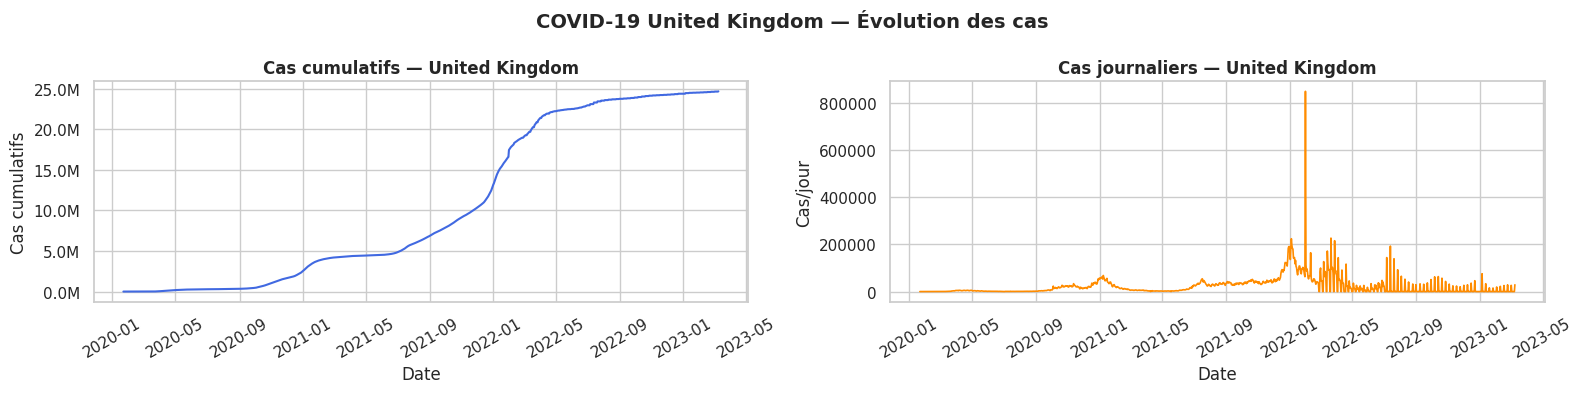

✅ fig_uk_cas.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df_uk['Date'], df_uk['Confirmed'], color='royalblue', lw=1.5)
axes[0].set_title("Cas cumulatifs — United Kingdom", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].plot(df_uk['Date'], df_uk['Daily_Confirmed'], color='darkorange', lw=1.2)
axes[1].set_title("Cas journaliers — United Kingdom", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Cas/jour")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("COVID-19 United Kingdom — Évolution des cas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_uk_cas.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_uk_cas.png sauvegardée")

### 28.2 Normalisation et séquences — United Kingdom

In [ ]:
scaler_uk = MinMaxScaler()
data_scaled_uk = scaler_uk.fit_transform(df_uk[['Confirmed']])

X_uk, y_uk = [], []
for i in range(len(data_scaled_uk) - SEQ_LEN_UK):
    X_uk.append(data_scaled_uk[i : i + SEQ_LEN_UK])
    y_uk.append(data_scaled_uk[i + SEQ_LEN_UK])
X_uk, y_uk = np.array(X_uk), np.array(y_uk)

n_uk = len(X_uk)
X_train_uk = torch.FloatTensor(X_uk[:int(n_uk*0.70)])
y_train_uk = torch.FloatTensor(y_uk[:int(n_uk*0.70)])
X_val_uk  = torch.FloatTensor(X_uk[int(n_uk*0.70):int(n_uk*0.85)])
y_val_uk  = torch.FloatTensor(y_uk[int(n_uk*0.70):int(n_uk*0.85)])
X_test_uk  = torch.FloatTensor(X_uk[int(n_uk*0.85):])
y_test_uk  = torch.FloatTensor(y_uk[int(n_uk*0.85):])

print(f"Train : {X_train_uk.shape} | Val : {X_val_uk.shape} | Test : {X_test_uk.shape}")

Train : torch.Size([758, 60, 1]) | Val : torch.Size([162, 60, 1]) | Test : torch.Size([163, 60, 1])


### 28.3 Fonction d'évaluation — United Kingdom

In [ ]:
def evaluate_uk(model, Xt, yt, name):
    return evaluate2(model, Xt, yt, name, scaler=scaler_uk)

print("✅ evaluate_uk définie")

✅ evaluate_uk définie


## 29. GRU amélioré — United Kingdom

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

gru_uk = GRUAmeliore()
print(f"GRU amélioré (United Kingdom) — Paramètres : {sum(p.numel() for p in gru_uk.parameters()):,}")

print("\n=== Entraînement GRU amélioré — United Kingdom ===")
gru_tl_uk, gru_vl_uk = train_ameliore(
    gru_uk, X_train_uk, y_train_uk, X_val_uk, y_val_uk, epochs=700
)

GRU amélioré (United Kingdom) — Paramètres : 157,697

=== Entraînement GRU amélioré — United Kingdom ===
Epoch   50 | Train: 0.000003 | Val: 0.000015
Epoch  100 | Train: 0.000003 | Val: 0.000012
  ⏹ Early stopping à epoch 103
  ✅ Meilleur Val Loss : 0.000001


## 30. LSTM amélioré — United Kingdom

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

lstm_uk = LSTMAmeliore()
print(f"LSTM amélioré (United Kingdom) — Paramètres : {sum(p.numel() for p in lstm_uk.parameters()):,}")

print("\n=== Entraînement LSTM amélioré — United Kingdom ===")
lstm_tl_uk, lstm_vl_uk = train_ameliore(
    lstm_uk, X_train_uk, y_train_uk, X_val_uk, y_val_uk, epochs=700
)

LSTM amélioré (United Kingdom) — Paramètres : 207,489

=== Entraînement LSTM amélioré — United Kingdom ===
Epoch   50 | Train: 0.000003 | Val: 0.000002
Epoch  100 | Train: 0.000003 | Val: 0.000003
  ⏹ Early stopping à epoch 104
  ✅ Meilleur Val Loss : 0.000001


## 31. BiLSTM amélioré — United Kingdom

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

bilstm_uk = BiLSTMAmeliore()
print(f"BiLSTM amélioré (United Kingdom) — Paramètres : {sum(p.numel() for p in bilstm_uk.parameters()):,}")

print("\n=== Entraînement BiLSTM amélioré — United Kingdom ===")
bilstm_tl_uk, bilstm_vl_uk = train_ameliore(
    bilstm_uk, X_train_uk, y_train_uk, X_val_uk, y_val_uk, epochs=700
)

BiLSTM amélioré (United Kingdom) — Paramètres : 545,921

=== Entraînement BiLSTM amélioré — United Kingdom ===
Epoch   50 | Train: 0.000003 | Val: 0.000002
Epoch  100 | Train: 0.000003 | Val: 0.000005
  ⏹ Early stopping à epoch 105
  ✅ Meilleur Val Loss : 0.000001


## 32. Courbes d'apprentissage — United Kingdom

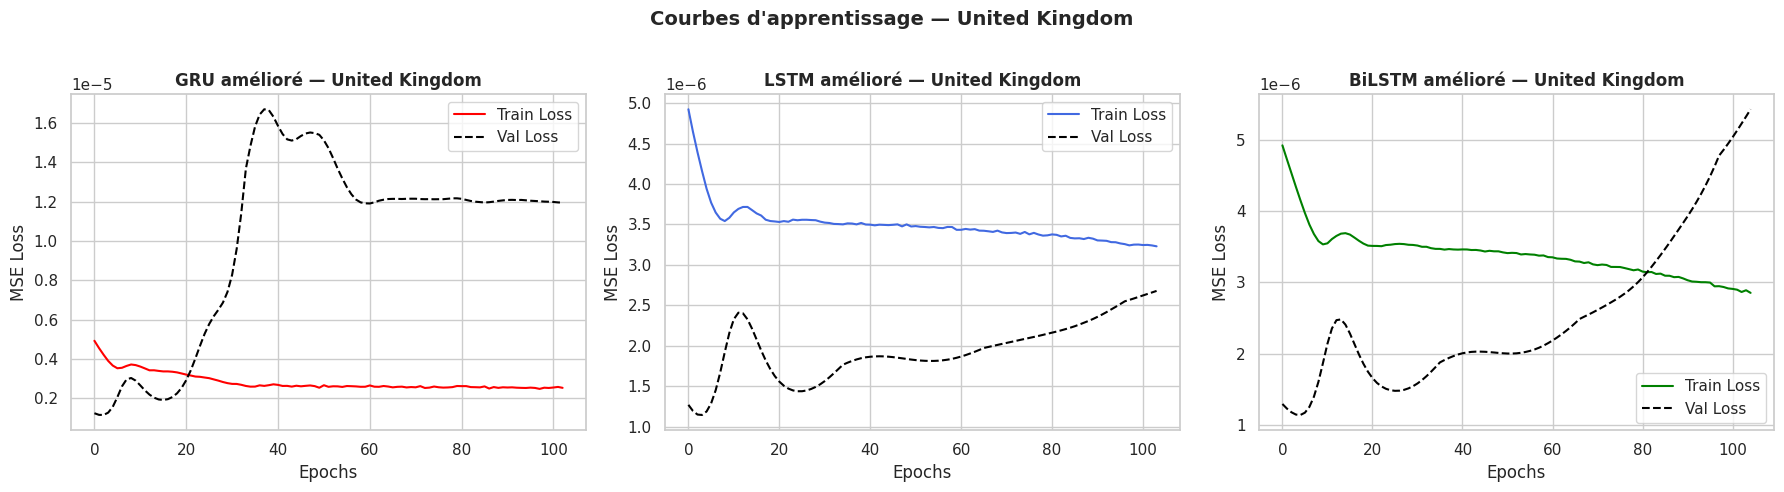

✅ fig_loss_uk.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_uk = [
    (gru_tl_uk,  gru_vl_uk,  "GRU amélioré",    "red"),
    (lstm_tl_uk, lstm_vl_uk, "LSTM amélioré",   "royalblue"),
    (bilstm_tl_uk,   bilstm_vl_uk,   "BiLSTM amélioré", "green"),
]

for ax, (tl, vl, name, col) in zip(axes, configs_uk):
    ax.plot(tl, label='Train Loss', color=col,    lw=1.5)
    ax.plot(vl, label='Val Loss',   color='black',lw=1.5, linestyle='--')
    ax.set_title(f"{name} — United Kingdom", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epochs"); ax.set_ylabel("MSE Loss")
    ax.legend()

plt.suptitle("Courbes d'apprentissage — United Kingdom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_loss_uk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_loss_uk.png sauvegardée")

## 33. Évaluation — United Kingdom

In [ ]:
print("\n" + "="*52)
print("   ÉVALUATION DES MODÈLES — UNITED KINGDOM")
print("="*52)

gru_preds_uk,  true_uk  = evaluate_uk(gru_uk,    X_test_uk, y_test_uk, "GRU amélioré")
lstm_preds_uk, _           = evaluate_uk(lstm_uk,   X_test_uk, y_test_uk, "LSTM amélioré")
bilstm_preds_uk,   true_uk2 = evaluate_uk(bilstm_uk, X_test_uk, y_test_uk, "BiLSTM amélioré")


   ÉVALUATION DES MODÈLES — UNITED KINGDOM

  GRU amélioré
  MAE  normalisé  : 0.000614
  RMSE normalisé  : 0.000669
  ─────────────────────────────────────
  MAE  réel       :          15,143.46  cas
  RMSE réel       :          16,487.89  cas
  ─────────────────────────────────────
  R²              : 0.9941  (99.41%)

  LSTM amélioré
  MAE  normalisé  : 0.000584
  RMSE normalisé  : 0.000646
  ─────────────────────────────────────
  MAE  réel       :          14,401.41  cas
  RMSE réel       :          15,926.29  cas
  ─────────────────────────────────────
  R²              : 0.9945  (99.45%)

  BiLSTM amélioré
  MAE  normalisé  : 0.000574
  RMSE normalisé  : 0.000638
  ─────────────────────────────────────
  MAE  réel       :          14,145.28  cas
  RMSE réel       :          15,743.97  cas
  ─────────────────────────────────────
  R²              : 0.9946  (99.46%)


## 34. Tableau comparatif — United Kingdom

In [ ]:
print("\n" + "="*70)
print(f"  {'Modèle':<22} {'MAE norm':>11}  {'RMSE norm':>11}  {'R²':>10}")
print("="*70)

results_uk = [
    ("GRU amélioré",    gru_preds_uk,  true_uk),
    ("LSTM amélioré",   lstm_preds_uk, true_uk),
    ("BiLSTM amélioré", bilstm_preds_uk,   true_uk2),
]

best_r2_uk = -np.inf
best_name_uk = ""

for name, preds, trues in results_uk:
    p_n    = scaler_uk.transform(preds)
    t_n    = scaler_uk.transform(trues)
    mae_n  = mean_absolute_error(t_n, p_n)
    rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
    r2_val = r2_score(trues, preds) * 100
    print(f"  {name:<22} {mae_n:>11.6f}  {rmse_n:>11.6f}  {r2_val:>9.2f}%")
    if r2_val > best_r2_uk:
        best_r2_uk   = r2_val
        best_name_uk = name

print("="*70)
print(f"  🏆 Meilleur modèle (United Kingdom) : {best_name_uk}  (R² = {best_r2_uk:.2f}%)")
print("="*70)


  Modèle                    MAE norm    RMSE norm          R²
  GRU amélioré              0.000614     0.000669      99.41%
  LSTM amélioré             0.000584     0.000646      99.45%
  BiLSTM amélioré           0.000574     0.000638      99.46%
  🏆 Meilleur modèle (United Kingdom) : BiLSTM amélioré  (R² = 99.46%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

## 35. Prédictions vs Réalité — United Kingdom

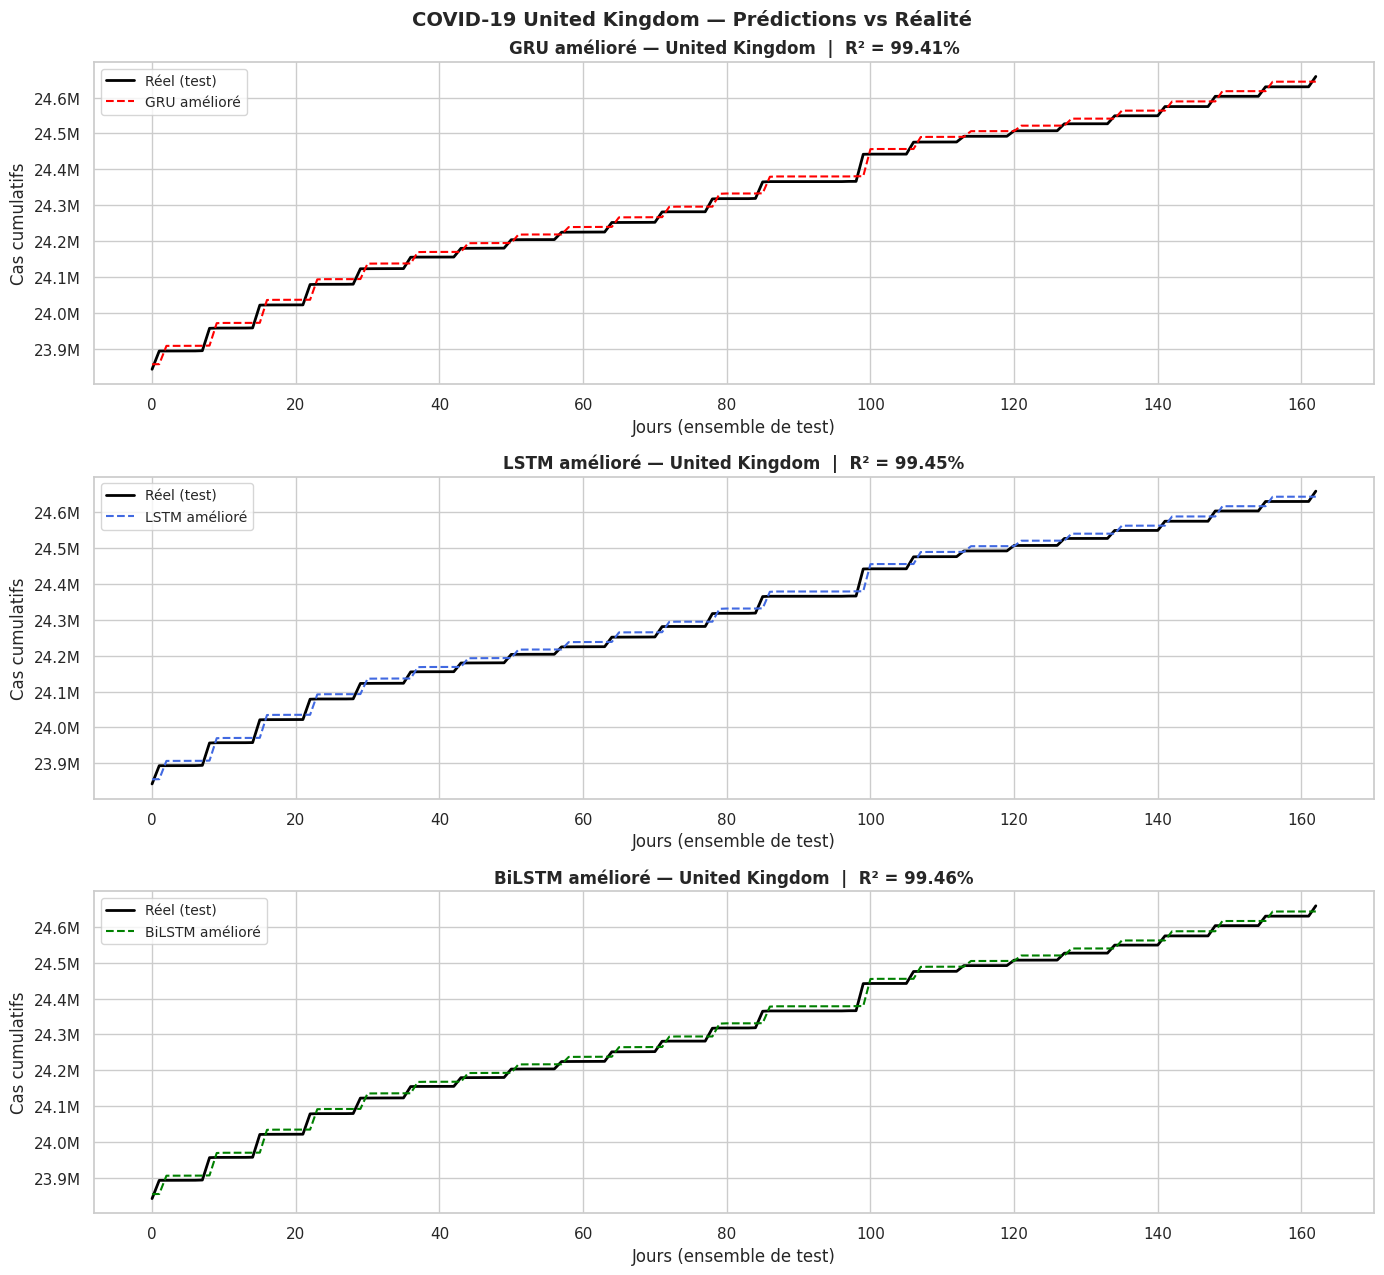

✅ fig_predictions_uk.png sauvegardée


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

plot_uk = [
    ("GRU amélioré",    gru_preds_uk,  true_uk,  "red"),
    ("LSTM amélioré",   lstm_preds_uk, true_uk,  "royalblue"),
    ("BiLSTM amélioré", bilstm_preds_uk,   true_uk2, "green"),
]

for ax, (name, preds, trues, col) in zip(axes, plot_uk):
    r2_val = r2_score(trues, preds) * 100
    ax.plot(trues, label='Réel (test)', color='black', lw=2.0)
    ax.plot(preds, label=name,          color=col,     lw=1.5, linestyle='--')
    ax.set_title(f"{name} — United Kingdom  |  R² = {r2_val:.2f}%", fontsize=12, fontweight='bold')
    ax.set_xlabel("Jours (ensemble de test)"); ax.set_ylabel("Cas cumulatifs")
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("COVID-19 United Kingdom — Prédictions vs Réalité", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_predictions_uk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_predictions_uk.png sauvegardée")

---
# 🇦🇺 PARTIE — Prédiction COVID-19 : Australia

Même pipeline : prétraitement · GRU amélioré · LSTM amélioré · BiLSTM amélioré.

## 34. Prétraitement — Cas cumulatifs confirmés : Australia

In [ ]:
COUNTRY_AUS = 'Australia'
SEQ_LEN_AUS = 60

df_aus = (df[df['Country/Region'] == COUNTRY_AUS]
            .groupby('Date')[['Confirmed', 'Deaths', 'Recovered']]
            .sum()
            .reset_index()
            .sort_values('Date'))

df_aus['Daily_Confirmed'] = df_aus['Confirmed'].diff().fillna(0).clip(lower=0)

print("✅ Données Australia extraites :", df_aus.shape)
print(df_aus[['Date','Confirmed','Daily_Confirmed']].tail(5))

✅ Données Australia extraites : (1143, 5)
           Date  Confirmed  Daily_Confirmed
1138 2023-03-05   11385534              0.0
1139 2023-03-06   11385534              0.0
1140 2023-03-07   11385534              0.0
1141 2023-03-08   11385534              0.0
1142 2023-03-09   11399460          13926.0


### 34.1 Visualisation — Australia

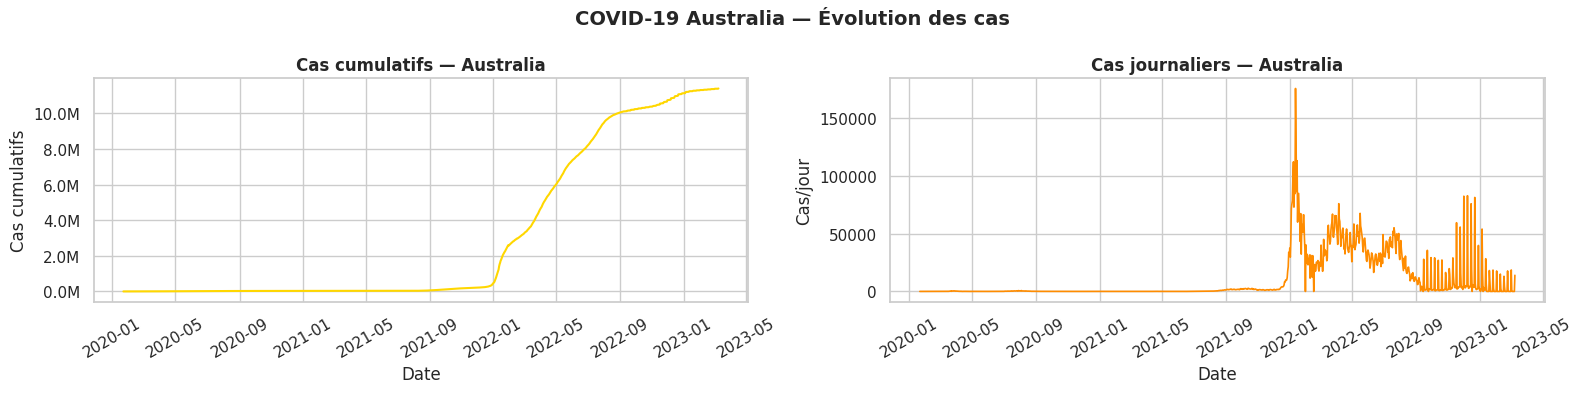

✅ fig_aus_cas.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df_aus['Date'], df_aus['Confirmed'], color='gold', lw=1.5)
axes[0].set_title("Cas cumulatifs — Australia", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].plot(df_aus['Date'], df_aus['Daily_Confirmed'], color='darkorange', lw=1.2)
axes[1].set_title("Cas journaliers — Australia", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Cas/jour")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("COVID-19 Australia — Évolution des cas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_aus_cas.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_aus_cas.png sauvegardée")

### 34.2 Normalisation et séquences — Australia

In [ ]:
scaler_aus = MinMaxScaler()
data_scaled_aus = scaler_aus.fit_transform(df_aus[['Confirmed']])

X_aus, y_aus = [], []
for i in range(len(data_scaled_aus) - SEQ_LEN_AUS):
    X_aus.append(data_scaled_aus[i : i + SEQ_LEN_AUS])
    y_aus.append(data_scaled_aus[i + SEQ_LEN_AUS])
X_aus, y_aus = np.array(X_aus), np.array(y_aus)

n_aus = len(X_aus)
X_train_aus = torch.FloatTensor(X_aus[:int(n_aus*0.70)])
y_train_aus = torch.FloatTensor(y_aus[:int(n_aus*0.70)])
X_val_aus  = torch.FloatTensor(X_aus[int(n_aus*0.70):int(n_aus*0.85)])
y_val_aus  = torch.FloatTensor(y_aus[int(n_aus*0.70):int(n_aus*0.85)])
X_test_aus  = torch.FloatTensor(X_aus[int(n_aus*0.85):])
y_test_aus  = torch.FloatTensor(y_aus[int(n_aus*0.85):])

print(f"Train : {X_train_aus.shape} | Val : {X_val_aus.shape} | Test : {X_test_aus.shape}")

Train : torch.Size([758, 60, 1]) | Val : torch.Size([162, 60, 1]) | Test : torch.Size([163, 60, 1])


### 34.3 Fonction d'évaluation — Australia

In [ ]:
def evaluate_aus(model, Xt, yt, name):
    return evaluate2(model, Xt, yt, name, scaler=scaler_aus)

print("✅ evaluate_aus définie")

✅ evaluate_aus définie


## 35. GRU amélioré — Australia

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

gru_aus = GRUAmeliore()
print(f"GRU amélioré (Australia) — Paramètres : {sum(p.numel() for p in gru_aus.parameters()):,}")

print("\n=== Entraînement GRU amélioré — Australia ===")
gru_tl_aus, gru_vl_aus = train_ameliore(
    gru_aus, X_train_aus, y_train_aus, X_val_aus, y_val_aus, epochs=700
)

GRU amélioré (Australia) — Paramètres : 157,697

=== Entraînement GRU amélioré — Australia ===
Epoch   50 | Train: 0.000002 | Val: 0.000064
Epoch  100 | Train: 0.000002 | Val: 0.000033
  ⏹ Early stopping à epoch 136
  ✅ Meilleur Val Loss : 0.000003


## 36. LSTM amélioré — Australia

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

lstm_aus = LSTMAmeliore()
print(f"LSTM amélioré (Australia) — Paramètres : {sum(p.numel() for p in lstm_aus.parameters()):,}")

print("\n=== Entraînement LSTM amélioré — Australia ===")
lstm_tl_aus, lstm_vl_aus = train_ameliore(
    lstm_aus, X_train_aus, y_train_aus, X_val_aus, y_val_aus, epochs=700
)

LSTM amélioré (Australia) — Paramètres : 207,489

=== Entraînement LSTM amélioré — Australia ===
Epoch   50 | Train: 0.000003 | Val: 0.000006
Epoch  100 | Train: 0.000003 | Val: 0.000005
  ⏹ Early stopping à epoch 109
  ✅ Meilleur Val Loss : 0.000005


## 37. BiLSTM amélioré — Australia

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

bilstm_aus = BiLSTMAmeliore()
print(f"BiLSTM amélioré (Australia) — Paramètres : {sum(p.numel() for p in bilstm_aus.parameters()):,}")

print("\n=== Entraînement BiLSTM amélioré — Australia ===")
bilstm_tl_aus, bilstm_vl_aus = train_ameliore(
    bilstm_aus, X_train_aus, y_train_aus, X_val_aus, y_val_aus, epochs=700
)

BiLSTM amélioré (Australia) — Paramètres : 545,921

=== Entraînement BiLSTM amélioré — Australia ===
Epoch   50 | Train: 0.000003 | Val: 0.000006
Epoch  100 | Train: 0.000003 | Val: 0.000005
  ⏹ Early stopping à epoch 111
  ✅ Meilleur Val Loss : 0.000005


## 38. Courbes d'apprentissage — Australia

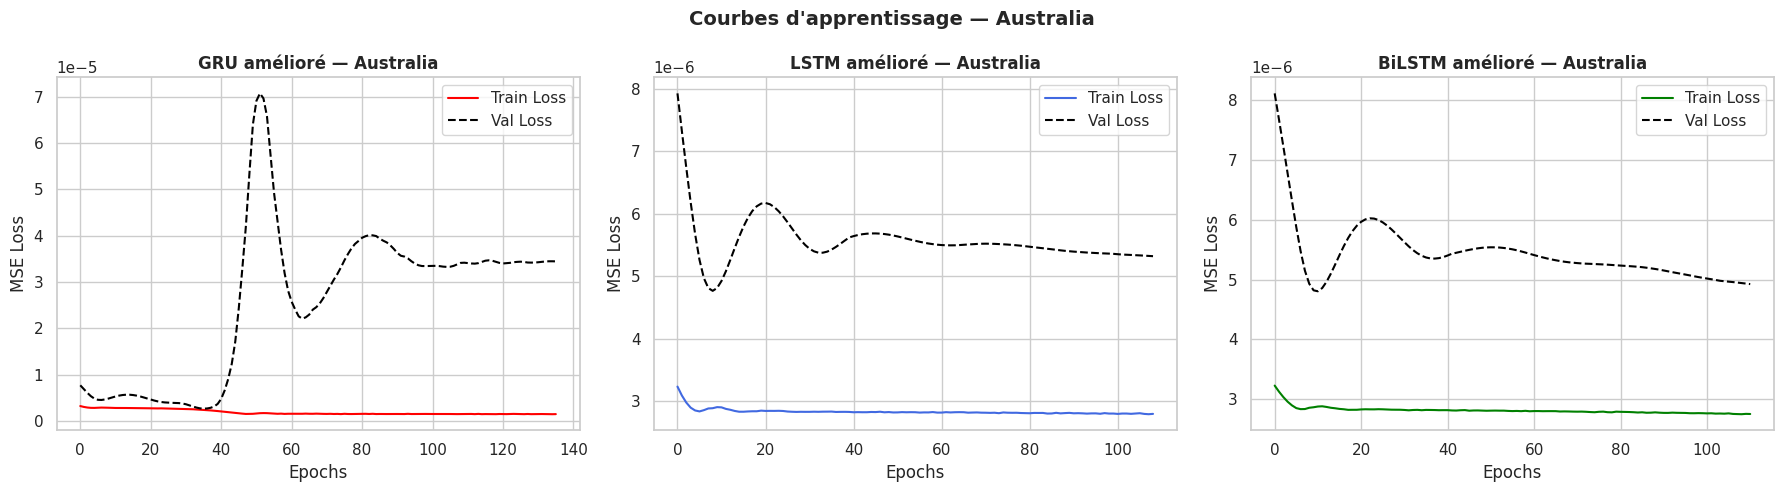

✅ fig_loss_aus.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_aus = [
    (gru_tl_aus,  gru_vl_aus,  "GRU amélioré",    "red"),
    (lstm_tl_aus, lstm_vl_aus, "LSTM amélioré",   "royalblue"),
    (bilstm_tl_aus,   bilstm_vl_aus,   "BiLSTM amélioré", "green"),
]

for ax, (tl, vl, name, col) in zip(axes, configs_aus):
    ax.plot(tl, label='Train Loss', color=col,    lw=1.5)
    ax.plot(vl, label='Val Loss',   color='black',lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Australia", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epochs"); ax.set_ylabel("MSE Loss")
    ax.legend()

plt.suptitle("Courbes d'apprentissage — Australia", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_loss_aus.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_loss_aus.png sauvegardée")

## 39. Évaluation — Australia

In [ ]:
print("\n" + "="*52)
print("   ÉVALUATION DES MODÈLES — AUSTRALIA")
print("="*52)

gru_preds_aus,  true_aus  = evaluate_aus(gru_aus,    X_test_aus, y_test_aus, "GRU amélioré")
lstm_preds_aus, _           = evaluate_aus(lstm_aus,   X_test_aus, y_test_aus, "LSTM amélioré")
bilstm_preds_aus,   true_aus2 = evaluate_aus(bilstm_aus, X_test_aus, y_test_aus, "BiLSTM amélioré")


   ÉVALUATION DES MODÈLES — AUSTRALIA

  GRU amélioré
  MAE  normalisé  : 0.002469
  RMSE normalisé  : 0.002560
  ─────────────────────────────────────
  MAE  réel       :          28,140.72  cas
  RMSE réel       :          29,182.85  cas
  ─────────────────────────────────────
  R²              : 0.9951  (99.51%)

  LSTM amélioré
  MAE  normalisé  : 0.000950
  RMSE normalisé  : 0.001365
  ─────────────────────────────────────
  MAE  réel       :          10,824.19  cas
  RMSE réel       :          15,558.74  cas
  ─────────────────────────────────────
  R²              : 0.9986  (99.86%)

  BiLSTM amélioré
  MAE  normalisé  : 0.000946
  RMSE normalisé  : 0.001364
  ─────────────────────────────────────
  MAE  réel       :          10,782.72  cas
  RMSE réel       :          15,547.61  cas
  ─────────────────────────────────────
  R²              : 0.9986  (99.86%)


## 40. Tableau comparatif — Australia

In [ ]:
print("\n" + "="*70)
print(f"  {'Modèle':<22} {'MAE norm':>11}  {'RMSE norm':>11}  {'R²':>10}")
print("="*70)

results_aus = [
    ("GRU amélioré",    gru_preds_aus,  true_aus),
    ("LSTM amélioré",   lstm_preds_aus, true_aus),
    ("BiLSTM amélioré", bilstm_preds_aus,   true_aus2),
]

best_r2_aus = -np.inf
best_name_aus = ""

for name, preds, trues in results_aus:
    p_n    = scaler_aus.transform(preds)
    t_n    = scaler_aus.transform(trues)
    mae_n  = mean_absolute_error(t_n, p_n)
    rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
    r2_val = r2_score(trues, preds) * 100
    print(f"  {name:<22} {mae_n:>11.6f}  {rmse_n:>11.6f}  {r2_val:>9.2f}%")
    if r2_val > best_r2_aus:
        best_r2_aus   = r2_val
        best_name_aus = name

print("="*70)
print(f"  🏆 Meilleur modèle (Australia) : {best_name_aus}  (R² = {best_r2_aus:.2f}%)")
print("="*70)


  Modèle                    MAE norm    RMSE norm          R²
  GRU amélioré              0.002469     0.002560      99.51%
  LSTM amélioré             0.000950     0.001365      99.86%
  BiLSTM amélioré           0.000946     0.001364      99.86%
  🏆 Meilleur modèle (Australia) : BiLSTM amélioré  (R² = 99.86%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

## 41. Prédictions vs Réalité — Australia

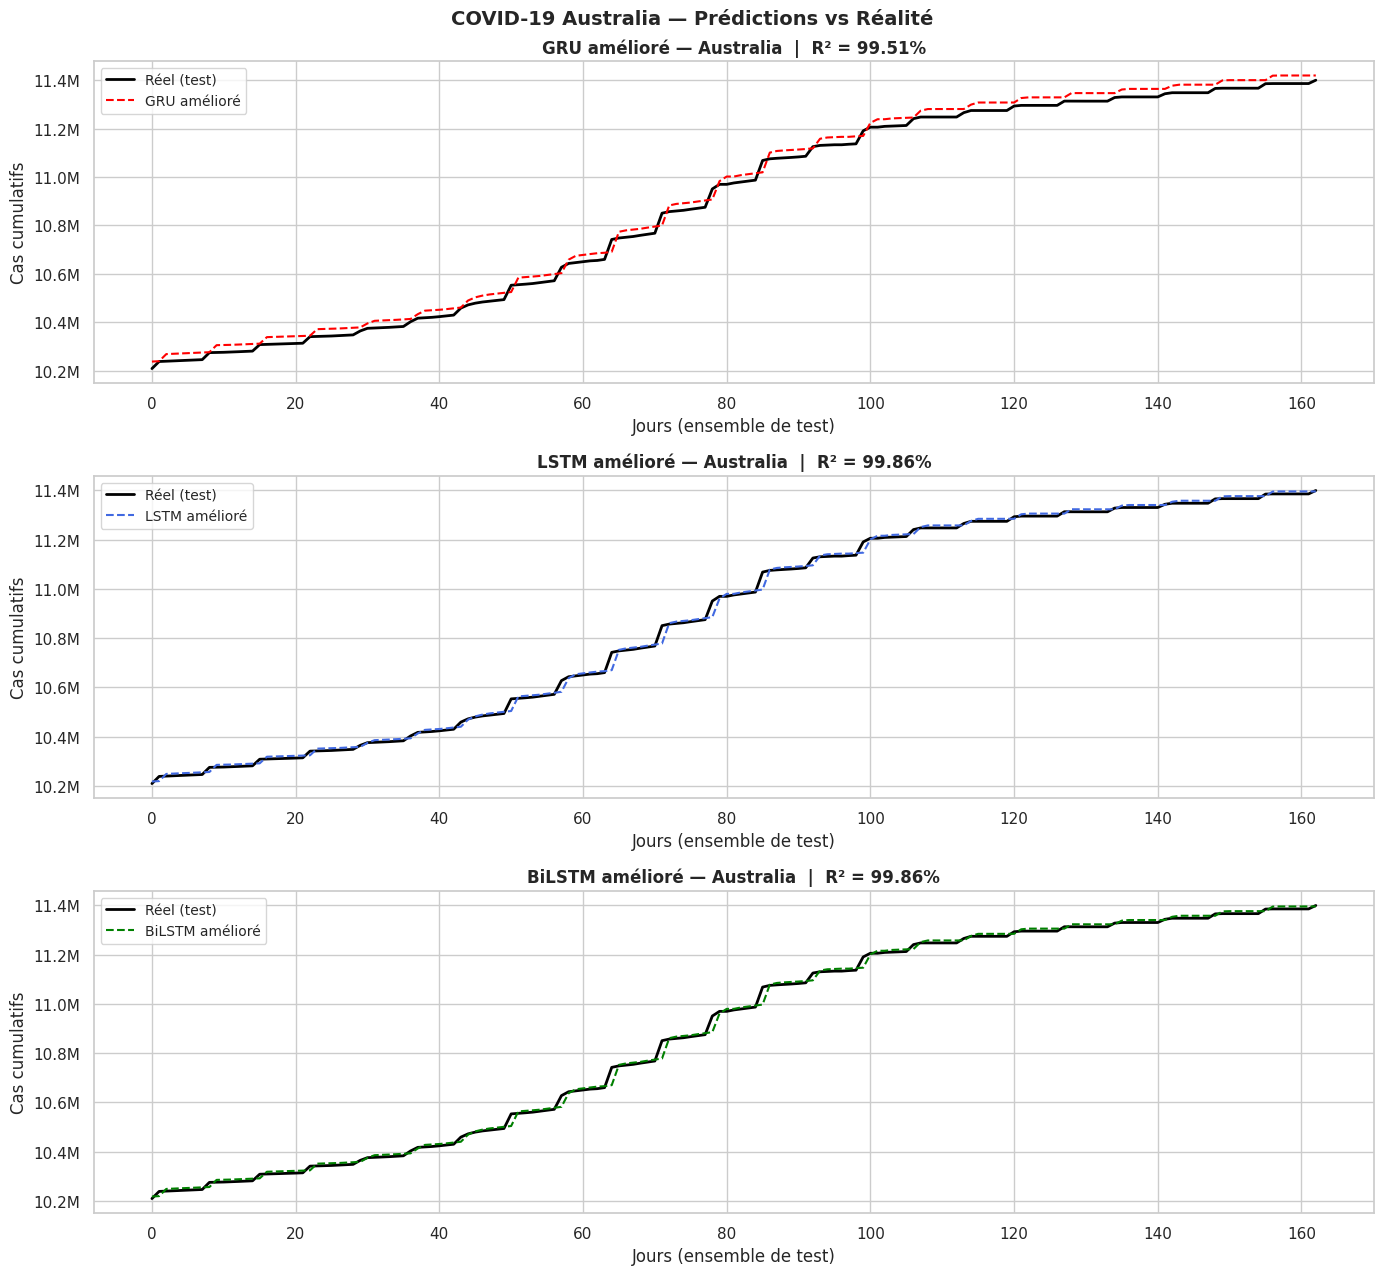

✅ fig_predictions_aus.png sauvegardée


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

plot_aus = [
    ("GRU amélioré",    gru_preds_aus,  true_aus,  "red"),
    ("LSTM amélioré",   lstm_preds_aus, true_aus,  "royalblue"),
    ("BiLSTM amélioré", bilstm_preds_aus,   true_aus2, "green"),
]

for ax, (name, preds, trues, col) in zip(axes, plot_aus):
    r2_val = r2_score(trues, preds) * 100
    ax.plot(trues, label='Réel (test)', color='black', lw=2.0)
    ax.plot(preds, label=name,          color=col,     lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Australia  |  R² = {r2_val:.2f}%", fontsize=12, fontweight='bold')
    ax.set_xlabel("Jours (ensemble de test)"); ax.set_ylabel("Cas cumulatifs")
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("COVID-19 Australia — Prédictions vs Réalité", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_predictions_aus.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_predictions_aus.png sauvegardée")

---
# 🇳🇱 PARTIE — Prédiction COVID-19 : Netherlands

Même pipeline : prétraitement · GRU amélioré · LSTM amélioré · BiLSTM amélioré.

## 40. Prétraitement — Cas cumulatifs confirmés : Netherlands

In [ ]:
COUNTRY_NL = 'Netherlands'
SEQ_LEN_NL = 60

df_nl = (df[df['Country/Region'] == COUNTRY_NL]
            .groupby('Date')[['Confirmed', 'Deaths', 'Recovered']]
            .sum()
            .reset_index()
            .sort_values('Date'))

df_nl['Daily_Confirmed'] = df_nl['Confirmed'].diff().fillna(0).clip(lower=0)

print("✅ Données Netherlands extraites :", df_nl.shape)
print(df_nl[['Date','Confirmed','Daily_Confirmed']].tail(5))

✅ Données Netherlands extraites : (1143, 5)
           Date  Confirmed  Daily_Confirmed
1138 2023-03-05    8710897              0.0
1139 2023-03-06    8710897              0.0
1140 2023-03-07    8712835           1938.0
1141 2023-03-08    8712835              0.0
1142 2023-03-09    8712835              0.0


### 40.1 Visualisation — Netherlands

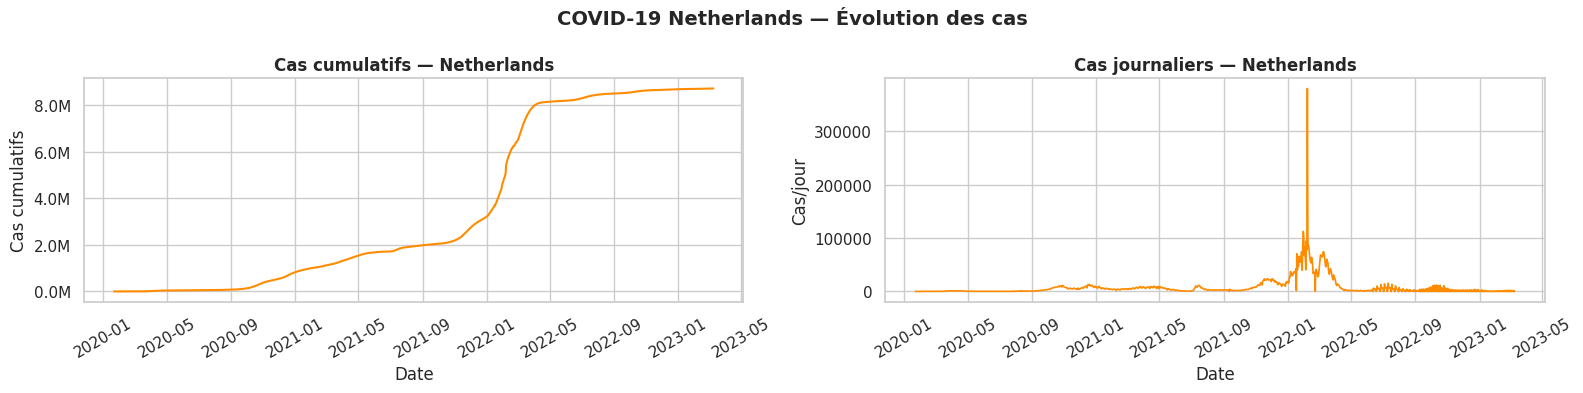

✅ fig_nl_cas.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df_nl['Date'], df_nl['Confirmed'], color='darkorange', lw=1.5)
axes[0].set_title("Cas cumulatifs — Netherlands", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Cas cumulatifs")
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].plot(df_nl['Date'], df_nl['Daily_Confirmed'], color='darkorange', lw=1.2)
axes[1].set_title("Cas journaliers — Netherlands", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Cas/jour")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("COVID-19 Netherlands — Évolution des cas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_nl_cas.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_nl_cas.png sauvegardée")

### 40.2 Normalisation et séquences — Netherlands

In [ ]:
scaler_nl = MinMaxScaler()
data_scaled_nl = scaler_nl.fit_transform(df_nl[['Confirmed']])

X_nl, y_nl = [], []
for i in range(len(data_scaled_nl) - SEQ_LEN_NL):
    X_nl.append(data_scaled_nl[i : i + SEQ_LEN_NL])
    y_nl.append(data_scaled_nl[i + SEQ_LEN_NL])
X_nl, y_nl = np.array(X_nl), np.array(y_nl)

n_nl = len(X_nl)
X_train_nl = torch.FloatTensor(X_nl[:int(n_nl*0.70)])
y_train_nl = torch.FloatTensor(y_nl[:int(n_nl*0.70)])
X_val_nl  = torch.FloatTensor(X_nl[int(n_nl*0.70):int(n_nl*0.85)])
y_val_nl  = torch.FloatTensor(y_nl[int(n_nl*0.70):int(n_nl*0.85)])
X_test_nl  = torch.FloatTensor(X_nl[int(n_nl*0.85):])
y_test_nl  = torch.FloatTensor(y_nl[int(n_nl*0.85):])

print(f"Train : {X_train_nl.shape} | Val : {X_val_nl.shape} | Test : {X_test_nl.shape}")

Train : torch.Size([758, 60, 1]) | Val : torch.Size([162, 60, 1]) | Test : torch.Size([163, 60, 1])


### 40.3 Fonction d'évaluation — Netherlands

In [ ]:
def evaluate_nl(model, Xt, yt, name):
    return evaluate2(model, Xt, yt, name, scaler=scaler_nl)

print("✅ evaluate_nl définie")

✅ evaluate_nl définie


## 41. GRU amélioré — Netherlands

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

gru_nl = GRUAmeliore()
print(f"GRU amélioré (Netherlands) — Paramètres : {sum(p.numel() for p in gru_nl.parameters()):,}")

print("\n=== Entraînement GRU amélioré — Netherlands ===")
gru_tl_nl, gru_vl_nl = train_ameliore(
    gru_nl, X_train_nl, y_train_nl, X_val_nl, y_val_nl, epochs=700
)

GRU amélioré (Netherlands) — Paramètres : 157,697

=== Entraînement GRU amélioré — Netherlands ===
Epoch   50 | Train: 0.000004 | Val: 0.000030
Epoch  100 | Train: 0.000004 | Val: 0.000030
  ⏹ Early stopping à epoch 102
  ✅ Meilleur Val Loss : 0.000000


## 42. LSTM amélioré — Netherlands

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

lstm_nl = LSTMAmeliore()
print(f"LSTM amélioré (Netherlands) — Paramètres : {sum(p.numel() for p in lstm_nl.parameters()):,}")

print("\n=== Entraînement LSTM amélioré — Netherlands ===")
lstm_tl_nl, lstm_vl_nl = train_ameliore(
    lstm_nl, X_train_nl, y_train_nl, X_val_nl, y_val_nl, epochs=700
)

LSTM amélioré (Netherlands) — Paramètres : 207,489

=== Entraînement LSTM amélioré — Netherlands ===
Epoch   50 | Train: 0.000006 | Val: 0.000001
Epoch  100 | Train: 0.000005 | Val: 0.000005
  ⏹ Early stopping à epoch 102
  ✅ Meilleur Val Loss : 0.000000


## 43. BiLSTM amélioré — Netherlands

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

bilstm_nl = BiLSTMAmeliore()
print(f"BiLSTM amélioré (Netherlands) — Paramètres : {sum(p.numel() for p in bilstm_nl.parameters()):,}")

print("\n=== Entraînement BiLSTM amélioré — Netherlands ===")
bilstm_tl_nl, bilstm_vl_nl = train_ameliore(
    bilstm_nl, X_train_nl, y_train_nl, X_val_nl, y_val_nl, epochs=700
)

BiLSTM amélioré (Netherlands) — Paramètres : 545,921

=== Entraînement BiLSTM amélioré — Netherlands ===
Epoch   50 | Train: 0.000006 | Val: 0.000002
Epoch  100 | Train: 0.000004 | Val: 0.000028
  ⏹ Early stopping à epoch 103
  ✅ Meilleur Val Loss : 0.000000


## 44. Courbes d'apprentissage — Netherlands

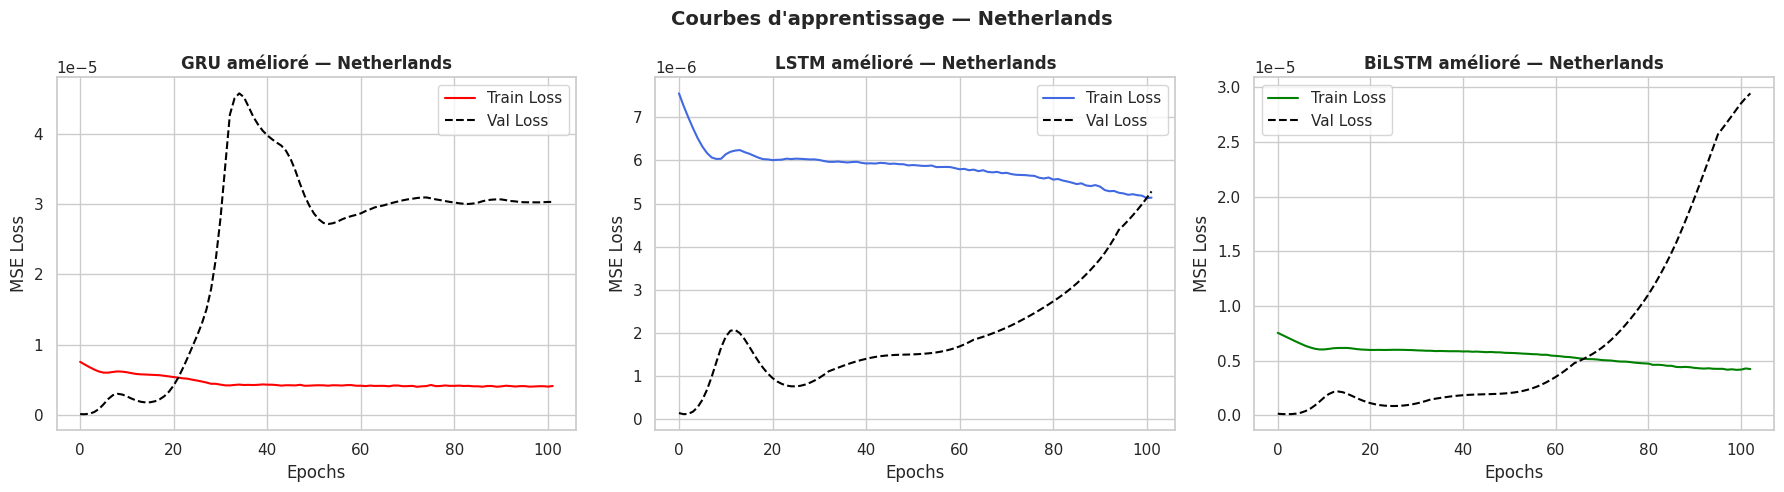

✅ fig_loss_nl.png sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_nl = [
    (gru_tl_nl,  gru_vl_nl,  "GRU amélioré",    "red"),
    (lstm_tl_nl, lstm_vl_nl, "LSTM amélioré",   "royalblue"),
    (bilstm_tl_nl,   bilstm_vl_nl,   "BiLSTM amélioré", "green"),
]

for ax, (tl, vl, name, col) in zip(axes, configs_nl):
    ax.plot(tl, label='Train Loss', color=col,    lw=1.5)
    ax.plot(vl, label='Val Loss',   color='black',lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Netherlands", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epochs"); ax.set_ylabel("MSE Loss")
    ax.legend()

plt.suptitle("Courbes d'apprentissage — Netherlands", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_loss_nl.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_loss_nl.png sauvegardée")

## 45. Évaluation — Netherlands

In [ ]:
print("\n" + "="*52)
print("   ÉVALUATION DES MODÈLES — NETHERLANDS")
print("="*52)

gru_preds_nl,  true_nl  = evaluate_nl(gru_nl,    X_test_nl, y_test_nl, "GRU amélioré")
lstm_preds_nl, _           = evaluate_nl(lstm_nl,   X_test_nl, y_test_nl, "LSTM amélioré")
bilstm_preds_nl,   true_nl2 = evaluate_nl(bilstm_nl, X_test_nl, y_test_nl, "BiLSTM amélioré")


   ÉVALUATION DES MODÈLES — NETHERLANDS

  GRU amélioré
  MAE  normalisé  : 0.000326
  RMSE normalisé  : 0.000365
  ─────────────────────────────────────
  MAE  réel       :           2,844.01  cas
  RMSE réel       :           3,181.34  cas
  ─────────────────────────────────────
  R²              : 0.9953  (99.53%)

  LSTM amélioré
  MAE  normalisé  : 0.000251
  RMSE normalisé  : 0.000308
  ─────────────────────────────────────
  MAE  réel       :           2,186.08  cas
  RMSE réel       :           2,685.35  cas
  ─────────────────────────────────────
  R²              : 0.9966  (99.66%)

  BiLSTM amélioré
  MAE  normalisé  : 0.000270
  RMSE normalisé  : 0.000322
  ─────────────────────────────────────
  MAE  réel       :           2,352.41  cas
  RMSE réel       :           2,802.82  cas
  ─────────────────────────────────────
  R²              : 0.9963  (99.63%)


## 46. Tableau comparatif — Netherlands

In [ ]:
print("\n" + "="*70)
print(f"  {'Modèle':<22} {'MAE norm':>11}  {'RMSE norm':>11}  {'R²':>10}")
print("="*70)

results_nl = [
    ("GRU amélioré",    gru_preds_nl,  true_nl),
    ("LSTM amélioré",   lstm_preds_nl, true_nl),
    ("BiLSTM amélioré", bilstm_preds_nl,   true_nl2),
]

best_r2_nl = -np.inf
best_name_nl = ""

for name, preds, trues in results_nl:
    p_n    = scaler_nl.transform(preds)
    t_n    = scaler_nl.transform(trues)
    mae_n  = mean_absolute_error(t_n, p_n)
    rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
    r2_val = r2_score(trues, preds) * 100
    print(f"  {name:<22} {mae_n:>11.6f}  {rmse_n:>11.6f}  {r2_val:>9.2f}%")
    if r2_val > best_r2_nl:
        best_r2_nl   = r2_val
        best_name_nl = name

print("="*70)
print(f"  🏆 Meilleur modèle (Netherlands) : {best_name_nl}  (R² = {best_r2_nl:.2f}%)")
print("="*70)


  Modèle                    MAE norm    RMSE norm          R²
  GRU amélioré              0.000326     0.000365      99.53%
  LSTM amélioré             0.000251     0.000308      99.66%
  BiLSTM amélioré           0.000270     0.000322      99.63%
  🏆 Meilleur modèle (Netherlands) : LSTM amélioré  (R² = 99.66%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

## 47. Prédictions vs Réalité — Netherlands

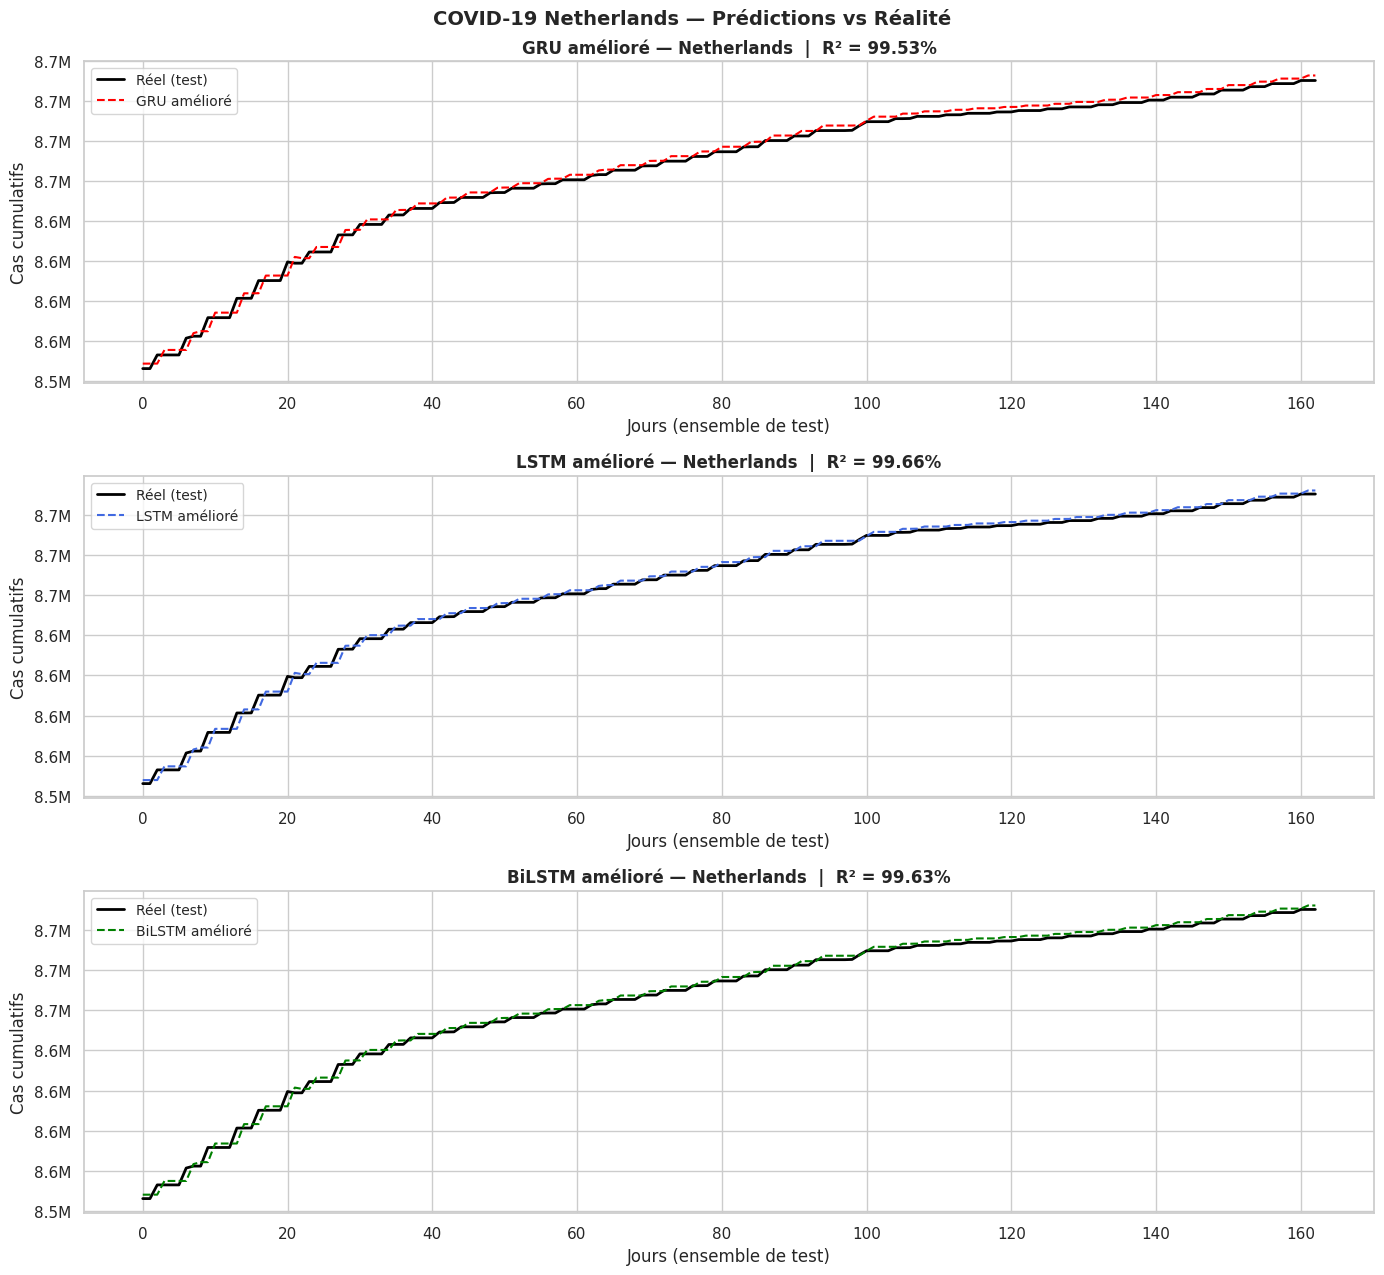

✅ fig_predictions_nl.png sauvegardée


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

plot_nl = [
    ("GRU amélioré",    gru_preds_nl,  true_nl,  "red"),
    ("LSTM amélioré",   lstm_preds_nl, true_nl,  "royalblue"),
    ("BiLSTM amélioré", bilstm_preds_nl,   true_nl2, "green"),
]

for ax, (name, preds, trues, col) in zip(axes, plot_nl):
    r2_val = r2_score(trues, preds) * 100
    ax.plot(trues, label='Réel (test)', color='black', lw=2.0)
    ax.plot(preds, label=name,          color=col,     lw=1.5, linestyle='--')
    ax.set_title(f"{name} — Netherlands  |  R² = {r2_val:.2f}%", fontsize=12, fontweight='bold')
    ax.set_xlabel("Jours (ensemble de test)"); ax.set_ylabel("Cas cumulatifs")
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.suptitle("COVID-19 Netherlands — Prédictions vs Réalité", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_predictions_nl.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ fig_predictions_nl.png sauvegardée")

---
## Résumé global — Tous les pays 🌍

In [ ]:
print("\n" + "="*72)
print("   RÉSUMÉ GLOBAL — FRANCE · CHINE · ROYAUME-UNI · AUSTRALIE · PAYS-BAS")
print("="*72)

all_countries = {
    "France 🇫🇷":        (scaler2,      [("GRU",    gru_preds2,      true_vals2),
                                          ("LSTM",   lstm_preds2,     true_vals2),
                                          ("BiLSTM", bilstm_preds,    true_vals_bi)]),
    "Chine 🇨🇳":         (scaler_cn,    [("GRU",    gru_preds_cn,    true_cn),
                                          ("LSTM",   lstm_preds_cn,   true_cn),
                                          ("BiLSTM", bilstm_preds_cn, true_cn2)]),
    "Royaume-Uni 🇬🇧":   (scaler_uk,   [("GRU",    gru_preds_uk,    true_uk),
                                          ("LSTM",   lstm_preds_uk,   true_uk),
                                          ("BiLSTM", bilstm_preds_uk, true_uk2)]),
    "Australie 🇦🇺":     (scaler_aus,  [("GRU",    gru_preds_aus,   true_aus),
                                          ("LSTM",   lstm_preds_aus,  true_aus),
                                          ("BiLSTM", bilstm_preds_aus,true_aus2)]),
    "Pays-Bas 🇳🇱":      (scaler_nl,   [("GRU",    gru_preds_nl,    true_nl),
                                          ("LSTM",   lstm_preds_nl,   true_nl),
                                          ("BiLSTM", bilstm_preds_nl, true_nl2)]),
}

print(f"  {'Pays':<20} {'Modèle':<10} {'MAE norm':>10}  {'RMSE norm':>10}  {'R²':>8}")
print("  " + "─"*64)

for country, (sc, results) in all_countries.items():
    for name, preds, trues in results:
        p_n    = sc.transform(preds)
        t_n    = sc.transform(trues)
        mae_n  = mean_absolute_error(t_n, p_n)
        rmse_n = np.sqrt(mean_squared_error(t_n, p_n))
        r2_val = r2_score(trues, preds) * 100
        print(f"  {country:<20} {name:<10} {mae_n:>10.6f}  {rmse_n:>10.6f}  {r2_val:>7.2f}%")
    print("  " + "─"*64)

print("="*72)


   RÉSUMÉ GLOBAL — FRANCE · CHINE · ROYAUME-UNI · AUSTRALIE · PAYS-BAS
  Pays                 Modèle       MAE norm   RMSE norm        R²
  ────────────────────────────────────────────────────────────────
  France 🇫🇷            GRU          0.000868    0.000959    99.92%
  France 🇫🇷            LSTM         0.000861    0.000952    99.93%
  France 🇫🇷            BiLSTM       0.000858    0.000947    99.93%
  ────────────────────────────────────────────────────────────────
  Chine 🇨🇳             GRU          0.002273    0.003343    99.96%
  Chine 🇨🇳             LSTM         0.002368    0.003729    99.95%
  Chine 🇨🇳             BiLSTM       0.002373    0.003734    99.95%
  ────────────────────────────────────────────────────────────────
  Royaume-Uni 🇬🇧       GRU          0.000614    0.000669    99.41%
  Royaume-Uni 🇬🇧       LSTM         0.000584    0.000646    99.45%
  Royaume-Uni 🇬🇧       BiLSTM       0.000574    0.000638    99.46%
  ───────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida